
#Text Classification: RNN vs Transformer (Pretrained, Minimal Training)

This notebook compares two deep learning architectures for text classification on **DBpedia-14** (14 Wikipedia article categories), both using PRETRAINED weights
with MINIMAL training (transfer learning).

  - **Model 1:** BiLSTM + Frozen GloVe Embeddings  (RNN-based)

  - **Model 2:** BERT  + Frozen Backbone           (Transformer-based)

The key constraint: pretrained layers are FROZEN — only task-specific layers
are trained. This demonstrates how well pretrained representations transfer
to a new classification task WITHOUT full fine-tuning.


# 0 - Install & Import Libraries

In [ ]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn tqdm nlpaug nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 27.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import zipfile
import subprocess
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# HuggingFace Datasets
from datasets import load_dataset

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Progress bar
from tqdm import tqdm

# %matplotlib inline

print("[INFO] All libraries imported successfully!")
print(f"[INFO] PyTorch version: {torch.__version__}")
print(f"[INFO] CUDA available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

[INFO] All libraries imported successfully!
[INFO] PyTorch version: 2.10.0+cu128
[INFO] CUDA available: True
[INFO] Using device: cuda


# 1 - Prepare Dataset (DBpedia-14)

# 1.1 - Load and prepare dataset
```
Dataset: DBpedia-14
  - 14 classes: Company, EducationalInstitution, Artist, Athlete,
    OfficeHolder, MeanOfTransportation, Building, NaturalPlace,
    Village, Animal, Plant, Album, Film, WrittenWork
  - Subsampled: 1,000 train + 300 test per class (14,000 / 4,200 total)
  - Balanced across all classes
```

In [ ]:
print("\n[INFO] Loading DBpedia-14 dataset from HuggingFace...")
dataset = load_dataset("fancyzhx/dbpedia_14")

print(f"[INFO] Dataset loaded!")
print(f"[INFO] Train size: {len(dataset['train'])}")
print(f"[INFO] Test size: {len(dataset['test'])}")

CLASS_NAMES = [
    'Company', 'EducationalInstitution', 'Artist', 'Athlete',
    'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace',
    'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"\n[INFO] Number of classes: {NUM_CLASSES}")
print(f"[INFO] Class names: {CLASS_NAMES}")

# Subsample
TRAIN_SAMPLES_PER_CLASS = 1000
TEST_SAMPLES_PER_CLASS = 300

print(f"\n[INFO] Subsampling:")
print(f"  Train: {TRAIN_SAMPLES_PER_CLASS} per class = {TRAIN_SAMPLES_PER_CLASS * NUM_CLASSES} total")
print(f"  Test: {TEST_SAMPLES_PER_CLASS} per class = {TEST_SAMPLES_PER_CLASS * NUM_CLASSES} total")


def subsample_dataset(split, samples_per_class, seed=42):
    indices = []
    for label in range(NUM_CLASSES):
        class_indices = [i for i, ex in enumerate(split) if ex['label'] == label]
        random.seed(seed)
        selected = random.sample(class_indices, min(samples_per_class, len(class_indices)))
        indices.extend(selected)
    random.seed(seed)
    random.shuffle(indices)
    return split.select(indices)


train_data = subsample_dataset(dataset['train'], TRAIN_SAMPLES_PER_CLASS)
test_data = subsample_dataset(dataset['test'], TEST_SAMPLES_PER_CLASS)

print(f"[INFO] Train: {len(train_data)}, Test: {len(test_data)}")


[INFO] Loading DBpedia-14 dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

[INFO] Dataset loaded!
[INFO] Train size: 560000
[INFO] Test size: 70000

[INFO] Number of classes: 14
[INFO] Class names: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']

[INFO] Subsampling:
  Train: 1000 per class = 14000 total
  Test: 300 per class = 4200 total
[INFO] Train: 14000, Test: 4200


# 1.2 - Explore the Dataset



--------------------------------------------------
1.3 - Dataset Exploration
--------------------------------------------------

[INFO] Training DataFrame shape: (14000, 4)
[INFO] First 5 samples:
                  title              category  label
0     Eucalyptus porosa                 Plant     10
1  Utricularia vulgaris                 Plant     10
2         Briegleb BG-7  MeanOfTransportation      5
3                Akrund               Village      8
4              Teletrax               Company      0

[INFO] Data types:
text        object
title       object
label        int64
category    object
dtype: object

[INFO] Null values:
text        0
title       0
label       0
category    0
dtype: int64

[INFO] Training class distribution:
category
Album                     1000
Animal                    1000
Artist                    1000
Athlete                   1000
Building                  1000
Company                   1000
EducationalInstitution    1000
Film                 

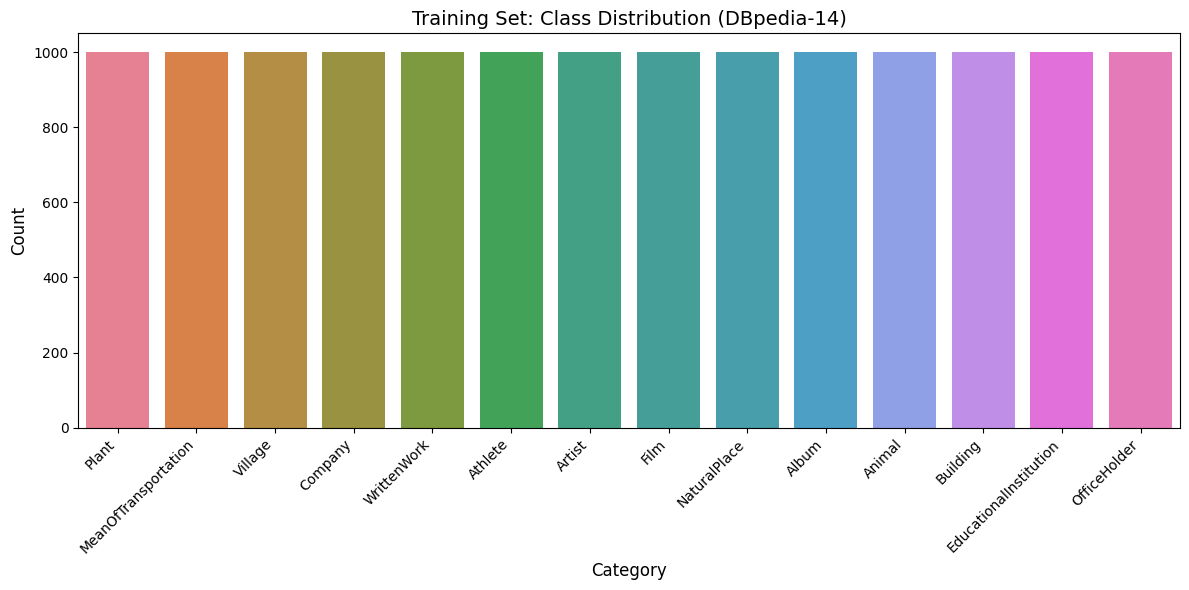

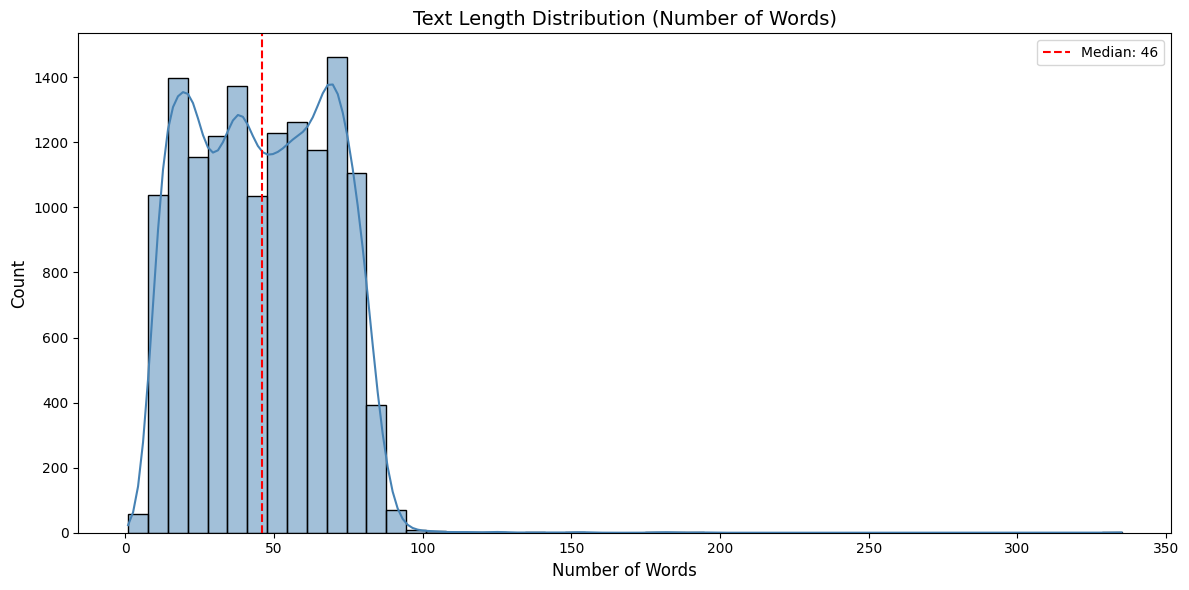


[INFO] Text length statistics:
count    14000.000000
mean        46.119786
std         22.231047
min          1.000000
25%         27.000000
50%         46.000000
75%         65.000000
max        335.000000
Name: text_length, dtype: float64

[INFO] Sample texts per category:

  [Album]  Welcoming Home the Astronauts is Flickerstick's first album. It was originally released in 2001 on 226 Records but afte...

  [Animal]  Pectinivalva scotodes is a moth of the Nepticulidae family. It is found in New South Wales and southern Queensland.The ...

  [Artist]  Thekra Mohammed Abdullah Al Dali (Arabic: ذكرى محمد عبدالله الدالي‎‎; September 16 1966 – November 28 2003) better know...

  [Athlete]  António Paulo Sanches Semedo (born 1 June 1979) is a Portuguese retired footballer. Operating on the left or right wing...

  [Building]  The Kane Mountain Fire Observation Station is a historic fire observation station located on Kane Mountain at Caroga in...

  [Company]  Teletraxis a broadcast moni

In [ ]:
print("\n" + "-"*50)
print("1.3 - Dataset Exploration")
print("-"*50)

df_train = pd.DataFrame({
    'text': [ex['content'] for ex in train_data],
    'title': [ex['title'] for ex in train_data],
    'label': [ex['label'] for ex in train_data],
    'category': [CLASS_NAMES[ex['label']] for ex in train_data]
})

df_test = pd.DataFrame({
    'text': [ex['content'] for ex in test_data],
    'title': [ex['title'] for ex in test_data],
    'label': [ex['label'] for ex in test_data],
    'category': [CLASS_NAMES[ex['label']] for ex in test_data]
})

print(f"\n[INFO] Training DataFrame shape: {df_train.shape}")
print(f"[INFO] First 5 samples:")
print(df_train[['title', 'category', 'label']].head())

print(f"\n[INFO] Data types:\n{df_train.dtypes}")
print(f"\n[INFO] Null values:\n{df_train.isnull().sum()}")

print(f"\n[INFO] Training class distribution:")
print(df_train['category'].value_counts().sort_index())

print(f"\n[INFO] Test class distribution:")
print(df_test['category'].value_counts().sort_index())

plt.figure(figsize=(12, 6))
palette = sns.color_palette("husl", NUM_CLASSES)
sns.countplot(data=df_train, x='category', hue='category',
              palette=palette, dodge=False, legend=False)
plt.title('Training Set: Class Distribution (DBpedia-14)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df_train['text_length'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x='text_length', bins=50, kde=True, color='steelblue')
plt.title('Text Length Distribution (Number of Words)', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(x=df_train['text_length'].median(), color='red',
            linestyle='--', label=f"Median: {df_train['text_length'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n[INFO] Text length statistics:")
print(df_train['text_length'].describe())

print(f"\n[INFO] Sample texts per category:")
for cat in sorted(df_train['category'].unique()):
    sample = df_train[df_train['category'] == cat]['text'].iloc[0]
    print(f"\n  [{cat}] {sample[:120]}...")

# 2 - Data Preprocessing
```
Preprocessing Pipeline:
  1. Lowercase all text
  2. Remove URLs and HTML tags
  3. Remove special characters (keep alphanumeric + spaces)
  4. Normalize whitespace

EDA:
  - Class distribution plots confirm balanced sampling
  - Text length distribution (word count) analyzed to set MAX_LEN
  - Word frequency analysis identifies common terms
```



[INFO] Text preprocessing completed!
[INFO] Original vs Processed:

  Original:   Eucalyptus porosa is a species of eucalypt or gum tree native to southern Australia. Common names i...
  Processed: eucalyptus porosa is a species of eucalypt or gum tree native to southern australia common names inc...

  Original:   Utricularia vulgaris (common bladderwort) is an aquatic species of bladderwort found in Asia and Eu...
  Processed: utricularia vulgaris common bladderwort is an aquatic species of bladderwort found in asia and europ...

  Original:   The Briegleb BG-7 is an American strut-braced high-wing single seat glider that was designed by Wil...
  Processed: the briegleb bg 7 is an american strut braced high wing single seat glider that was designed by will...

[INFO] Total words: 667226
[INFO] Unique words: 56136

[INFO] Top 20 most common words:
  the: 41447
  in: 23449
  of: 22091
  a: 19392
  is: 18901
  and: 18152
  was: 9620
  by: 7126
  to: 6870
  it: 6775
  as: 5213
  on: 466

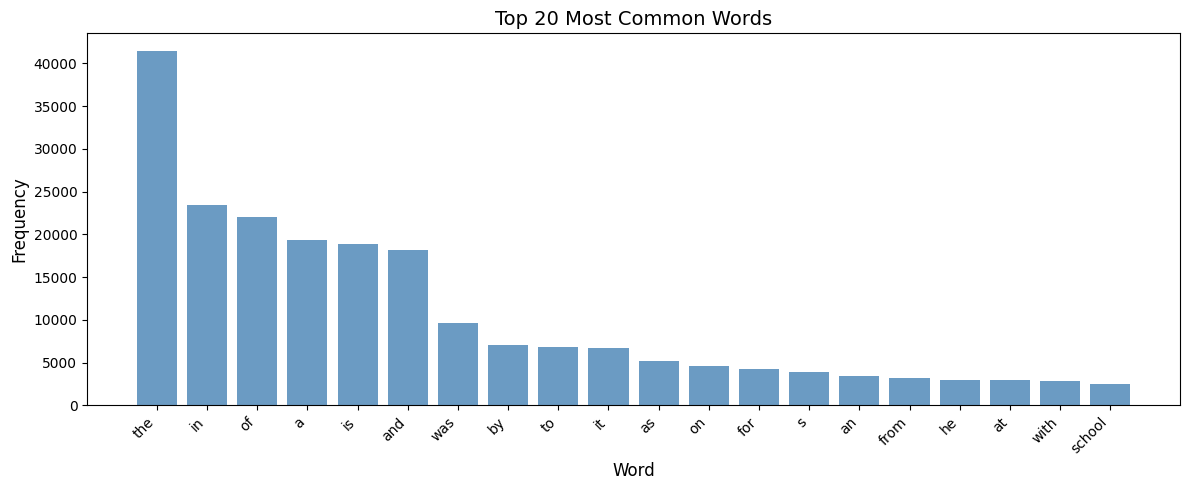

In [ ]:
def preprocess_text(text):
    """
    Preprocess text:
      1. Lowercase
      2. Remove URLs and HTML
      3. Remove special characters
      4. Normalize whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df_train['processed_text'] = df_train['text'].apply(preprocess_text)
df_test['processed_text'] = df_test['text'].apply(preprocess_text)

print("\n[INFO] Text preprocessing completed!")
print("[INFO] Original vs Processed:")
for i in range(3):
    print(f"\n  Original:  {df_train['text'].iloc[i][:100]}...")
    print(f"  Processed: {df_train['processed_text'].iloc[i][:100]}...")

# Word frequency
all_words = ' '.join(df_train['processed_text']).split()
word_freq = Counter(all_words).most_common(20)
print(f"\n[INFO] Total words: {len(all_words)}")
print(f"[INFO] Unique words: {len(set(all_words))}")
print(f"\n[INFO] Top 20 most common words:")
for w, f in word_freq:
    print(f"  {w}: {f}")

words_list, freqs_list = zip(*word_freq)
plt.figure(figsize=(12, 5))
plt.bar(words_list, freqs_list, color='steelblue', alpha=0.8)
plt.title('Top 20 Most Common Words', fontsize=14)
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3 - Model 1: BiLSTM with Pretrained GloVe (Frozen Embeddings)
```
PRINCIPLE:

  Transfer Learning via Static Word Embeddings.

  GloVe (Global Vectors for Word Representation) provides pretrained word
  vectors trained on 6 billion tokens (Wikipedia + Gigaword). These vectors
  capture semantic relationships: king - man + woman ≈ queen.

  We load these pretrained vectors into the nn.Embedding layer and FREEZE it
  (requires_grad = False). Only the LSTM and FC layers are trained.

WHAT IS FROZEN vs TRAINED:
  FROZEN:  Embedding layer (GloVe 6B 100d, pretrained, NOT updated)
  TRAINED: BiLSTM layers + FC classification head
  ```


```
ARCHITECTURE:

Input text → Tokenize (custom vocab) → Pad to MAX_LEN=256
      ↓
  [1] Embedding Layer (FROZEN GloVe, 100d)
      - Vocab built from training data (words with freq ≥ 2)
      - Words found in GloVe → pretrained vector
      - Words NOT in GloVe → random initialization
      ↓
  [2] Dropout (0.3)
      ↓
  [3] Bidirectional LSTM (2 layers, hidden_dim=128)
      - Processes tokens left→right AND right→left
      - Output: (batch, seq_len, 2 × 128 = 256)
      ↓
  [4] Mean Pooling over sequence dimension
      - Aggregates all time steps into one vector
      - Output: (batch, 256)
      ↓
  [5] Dropout → Linear(256, 128) → ReLU → Dropout → Linear(128, 14)
      - Classification head
      ↓
  Output: logits for 14 classes
  ```


## 3.1 - Download GloVe

In [ ]:
GLOVE_DIR = "./glove"
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")
GLOVE_DIM = 100

if not os.path.exists(GLOVE_FILE):
    print("[INFO] Downloading GloVe embeddings (~862 MB)...")
    os.makedirs(GLOVE_DIR, exist_ok=True)
    glove_zip = os.path.join(GLOVE_DIR, "glove.6B.zip")
    subprocess.run(
        ["wget", "-q", "--show-progress",
         "https://nlp.stanford.edu/data/glove.6B.zip",
         "-O", glove_zip],
        check=True
    )
    print("[INFO] Extracting...")
    with zipfile.ZipFile(glove_zip, 'r') as z:
        z.extractall(GLOVE_DIR)
    os.remove(glove_zip)
    print("[INFO] GloVe ready!")
else:
    print(f"[INFO] GloVe already present at {GLOVE_FILE}")


[INFO] Downloading GloVe embeddings (~862 MB)...
[INFO] Extracting...
[INFO] GloVe ready!


## 3.2 - Load GloVe

In [ ]:
print("\n[INFO] Loading GloVe word vectors...")
glove_vectors = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Loading GloVe", total=400000):
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vector

print(f"[INFO] GloVe vocabulary size: {len(glove_vectors)}")
print(f"[INFO] Embedding dimension: {GLOVE_DIM}")


[INFO] Loading GloVe word vectors...


Loading GloVe: 100%|██████████| 400000/400000 [00:09<00:00, 44300.62it/s]

[INFO] GloVe vocabulary size: 400000
[INFO] Embedding dimension: 100


## 3.3 - Build Vocabulary & Create GloVe Embedding Matrix

In [ ]:
print("\n[INFO] Building vocabulary for BiLSTM...")

all_train_words = []
for text in df_train['processed_text']:
    all_train_words.extend(text.split())

word_counts = Counter(all_train_words)
MIN_FREQ = 2

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
idx = 2
for word, count in word_counts.most_common():
    if count >= MIN_FREQ:
        vocab[word] = idx
        idx += 1

VOCAB_SIZE = len(vocab)
print(f"[INFO] Vocabulary size: {VOCAB_SIZE}")

# Create pretrained embedding matrix
print("[INFO] Creating pretrained GloVe embedding matrix...")
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found_count = 0

for word, word_idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[word_idx] = glove_vectors[word]
        found_count += 1
    else:
        # Random init for OOV words
        embedding_matrix[word_idx] = np.random.normal(0, 0.1, GLOVE_DIM)

print(f"[INFO] Words found in GloVe: {found_count}/{VOCAB_SIZE} "
      f"({found_count/VOCAB_SIZE*100:.1f}%)")
print(f"[DEBUG] Embedding matrix shape: {embedding_matrix.shape}")
print(f"[DEBUG] Embedding matrix dtype: {embedding_matrix.dtype}")



[INFO] Building vocabulary for BiLSTM...
[INFO] Vocabulary size: 25260
[INFO] Creating pretrained GloVe embedding matrix...
[INFO] Words found in GloVe: 23231/25260 (92.0%)
[DEBUG] Embedding matrix shape: (25260, 100)
[DEBUG] Embedding matrix dtype: float64


## 3.4 - Tokenize and Pad

In [ ]:
MAX_LEN_RNN = 256


def tokenize_for_rnn(text, vocab, max_len):
    words = text.split()[:max_len]
    indices = [vocab.get(w, vocab[UNK_TOKEN]) for w in words]
    if len(indices) < max_len:
        indices += [vocab[PAD_TOKEN]] * (max_len - len(indices))
    return indices


train_tokens_rnn = torch.LongTensor(
    [tokenize_for_rnn(t, vocab, MAX_LEN_RNN) for t in df_train['processed_text']]
)
test_tokens_rnn = torch.LongTensor(
    [tokenize_for_rnn(t, vocab, MAX_LEN_RNN) for t in df_test['processed_text']]
)
train_labels = torch.LongTensor(df_train['label'].values)
test_labels = torch.LongTensor(df_test['label'].values)

print(f"\n[DEBUG] Train tokens shape: {train_tokens_rnn.shape}")
print(f"[DEBUG] Test tokens shape: {test_tokens_rnn.shape}")
print(f"[DEBUG] Train labels shape: {train_labels.shape}")
print(f"[DEBUG] Sample tokenized (first 20): {train_tokens_rnn[0][:20]}")



[DEBUG] Train tokens shape: torch.Size([14000, 256])
[DEBUG] Test tokens shape: torch.Size([4200, 256])
[DEBUG] Train labels shape: torch.Size([14000])
[DEBUG] Sample tokenized (first 20): tensor([ 4245, 12320,     6,     5,    31,     4, 16412,    45,  8404,   575,
          189,    10,   216,   207,   310,   760,   526,   345,  5095,   345])


## 3.7 - DataLoader

In [ ]:
class TextDataset(Dataset):
    def __init__(self, tokens, labels):
        self.tokens = tokens
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tokens[idx], self.labels[idx]


BATCH_SIZE_RNN = 64

train_dataset_rnn = TextDataset(train_tokens_rnn, train_labels)
test_dataset_rnn = TextDataset(test_tokens_rnn, test_labels)

train_loader_rnn = DataLoader(train_dataset_rnn, batch_size=BATCH_SIZE_RNN,
                               shuffle=True, drop_last=False)
test_loader_rnn = DataLoader(test_dataset_rnn, batch_size=BATCH_SIZE_RNN, shuffle=False)

print(f"\n[INFO] DataLoader:")
print(f"  Train batches: {len(train_loader_rnn)}")
print(f"  Test batches: {len(test_loader_rnn)}")
print(f"  Batch size: {BATCH_SIZE_RNN}")



[INFO] DataLoader:
  Train batches: 219
  Test batches: 66
  Batch size: 64


## 3.6 - BiLSTM Model with Pretrained GloVe Embeddings
```
KEY DESIGN DECISIONS:
  - GloVe 100d (not 300d): smaller, sufficient for this task
  - MIN_FREQ=2: removes rare words to keep vocab manageable
  - Mean pooling (not last hidden state): better for classification
    because it considers ALL positions, not just the last one
  - Bidirectional: captures context from both directions
```

In [ ]:
class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM for Text Classification with Pretrained Embeddings.

    Key difference from training version:
      - Embedding layer is initialized with PRETRAINED GloVe vectors
      - Embedding layer is FROZEN (requires_grad=False)
      - Only LSTM + FC layers are trained

    Architecture:
      1. Embedding Layer: PRETRAINED GloVe (FROZEN, not trained)
      2. BiLSTM: processes sequence bidirectionally (TRAINED)
      3. Mean Pooling: aggregate over sequence
      4. FC layers: classification head (TRAINED)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None, freeze_embeddings=True):
        super(BiLSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Load pretrained GloVe embeddings
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(
                torch.FloatTensor(pretrained_embeddings)
            )
            print(f"  [INFO] Loaded pretrained embeddings into Embedding layer")

        # FREEZE embedding layer
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
            print(f"  [INFO] Embedding layer FROZEN (not trainable)")

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)       # (batch, seq_len, embed_dim) - FROZEN GloVe
        embedded = self.dropout(embedded)

        lstm_out, (hidden, cell) = self.lstm(embedded)
        # lstm_out: (batch, seq_len, 2 * hidden_dim)

        pooled = lstm_out.mean(dim=1)      # (batch, 2 * hidden_dim)

        out = self.dropout(pooled)
        out = self.fc1(out)                # (batch, hidden_dim)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)                # (batch, num_classes)
        return out


EMBED_DIM = GLOVE_DIM  # 100 (same as GloVe)
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3

bilstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pretrained_embeddings=embedding_matrix,
    freeze_embeddings=True  # KEY: Freeze GloVe embeddings
).to(device)

print(f"\n[INFO] BiLSTM Model Architecture:")
print(bilstm_model)

total_params_rnn = sum(p.numel() for p in bilstm_model.parameters())
trainable_params_rnn = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
frozen_params_rnn = total_params_rnn - trainable_params_rnn

print(f"\n[INFO] Total parameters: {total_params_rnn:,}")
print(f"[INFO] Trainable parameters: {trainable_params_rnn:,} (LSTM + FC only)")
print(f"[INFO] Frozen parameters: {frozen_params_rnn:,} (GloVe Embeddings)")
print(f"[INFO] Frozen ratio: {frozen_params_rnn/total_params_rnn*100:.1f}%")


  [INFO] Loaded pretrained embeddings into Embedding layer
  [INFO] Embedding layer FROZEN (not trainable)

[INFO] BiLSTM Model Architecture:
BiLSTMClassifier(
  (embedding): Embedding(25260, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=14, bias=True)
)

[INFO] Total parameters: 3,191,486
[INFO] Trainable parameters: 665,486 (LSTM + FC only)
[INFO] Frozen parameters: 2,526,000 (GloVe Embeddings)
[INFO] Frozen ratio: 79.1%


## 3.7 - Train BiLSTM (only LSTM + FC, embeddings frozen)
```
TRAINING CONFIG:
  - Optimizer: Adam (only trainable params, excluding frozen embeddings)
  - Learning Rate: 1e-3
  - Scheduler: StepLR (step=5, gamma=0.5)
  - Loss: CrossEntropyLoss
  - Epochs: 10
  - Gradient Clipping: max_norm=1.0
  - Batch Size: 64
```

In [ ]:

print("\n--- Training BiLSTM (Pretrained GloVe Frozen, LSTM+FC Trained) ---")

EPOCHS_RNN = 10
LR_RNN = 1e-3

criterion_rnn = nn.CrossEntropyLoss()
# Only optimize trainable parameters (not frozen embeddings)
optimizer_rnn = optim.Adam(filter(lambda p: p.requires_grad, bilstm_model.parameters()),
                            lr=LR_RNN)
scheduler_rnn = optim.lr_scheduler.StepLR(optimizer_rnn, step_size=5, gamma=0.5)

print(f"\n[INFO] Training hyperparameters:")
print(f"  Epochs: {EPOCHS_RNN}")
print(f"  Learning rate: {LR_RNN}")
print(f"  Optimizer: Adam (only trainable params)")
print(f"  Scheduler: StepLR (step=5, gamma=0.5)")
print(f"  Loss: CrossEntropyLoss")
print(f"  NOTE: Embedding layer is FROZEN (GloVe pretrained)")

rnn_train_losses = []
rnn_train_accs = []
rnn_test_accs = []

for epoch in range(EPOCHS_RNN):
    bilstm_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (tokens, labels) in enumerate(tqdm(train_loader_rnn,
                                                       desc=f"Epoch {epoch+1}/{EPOCHS_RNN}")):
        tokens = tokens.to(device)
        labels = labels.to(device)

        if epoch == 0 and batch_idx == 0:
            print(f"\n  [DEBUG] Input tokens shape: {tokens.shape}")
            print(f"  [DEBUG] Labels shape: {labels.shape}")

        logits = bilstm_model(tokens)

        if epoch == 0 and batch_idx == 0:
            print(f"  [DEBUG] Logits shape: {logits.shape}")
            print(f"  [DEBUG] Logits sample: {logits[0].detach().cpu()}")
            # Verify embedding is frozen
            print(f"  [DEBUG] Embedding requires_grad: {bilstm_model.embedding.weight.requires_grad}")

        loss = criterion_rnn(logits, labels)

        if epoch == 0 and batch_idx == 0:
            print(f"  [DEBUG] Loss: {loss.item():.4f}")

        optimizer_rnn.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), max_norm=1.0)
        optimizer_rnn.step()

        running_loss += loss.item() * tokens.size(0)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler_rnn.step()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    rnn_train_losses.append(epoch_loss)
    rnn_train_accs.append(epoch_acc)

    # Test evaluation
    bilstm_model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for tokens, labels in test_loader_rnn:
            tokens, labels = tokens.to(device), labels.to(device)
            logits = bilstm_model(tokens)
            _, predicted = logits.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = test_correct / test_total
    rnn_test_accs.append(test_acc)

    print(f"  Epoch [{epoch+1}/{EPOCHS_RNN}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Test Acc: {test_acc:.4f} | "
          f"LR: {scheduler_rnn.get_last_lr()[0]:.6f}")


--- Training BiLSTM (Pretrained GloVe Frozen, LSTM+FC Trained) ---

[INFO] Training hyperparameters:
  Epochs: 10
  Learning rate: 0.001
  Optimizer: Adam (only trainable params)
  Scheduler: StepLR (step=5, gamma=0.5)
  Loss: CrossEntropyLoss
  NOTE: Embedding layer is FROZEN (GloVe pretrained)


Epoch 1/10:   0%|          | 0/219 [00:00<?, ?it/s]


  [DEBUG] Input tokens shape: torch.Size([64, 256])
  [DEBUG] Labels shape: torch.Size([64])
  [DEBUG] Logits shape: torch.Size([64, 14])
  [DEBUG] Logits sample: tensor([ 0.0682, -0.0727, -0.0284,  0.0737, -0.0801, -0.0776, -0.0126, -0.1205,
         0.0137, -0.0546,  0.0287, -0.0523,  0.0802, -0.0741])
  [DEBUG] Embedding requires_grad: False
  [DEBUG] Loss: 2.6500


Epoch 1/10: 100%|██████████| 219/219 [00:02<00:00, 74.20it/s] 


  Epoch [1/10] Loss: 1.8131 | Train Acc: 0.3147 | Test Acc: 0.5248 | LR: 0.001000


...

  Epoch [8/10] Loss: 0.1642 | Train Acc: 0.9544 | Test Acc: 0.9667 | LR: 0.000500


Epoch 9/10: 100%|██████████| 219/219 [00:02<00:00, 109.03it/s]


  Epoch [9/10] Loss: 0.1504 | Train Acc: 0.9612 | Test Acc: 0.9676 | LR: 0.000500


Epoch 10/10: 100%|██████████| 219/219 [00:02<00:00, 108.63it/s]


  Epoch [10/10] Loss: 0.1310 | Train Acc: 0.9674 | Test Acc: 0.9671 | LR: 0.000250


## 3.8 - Plot Curves

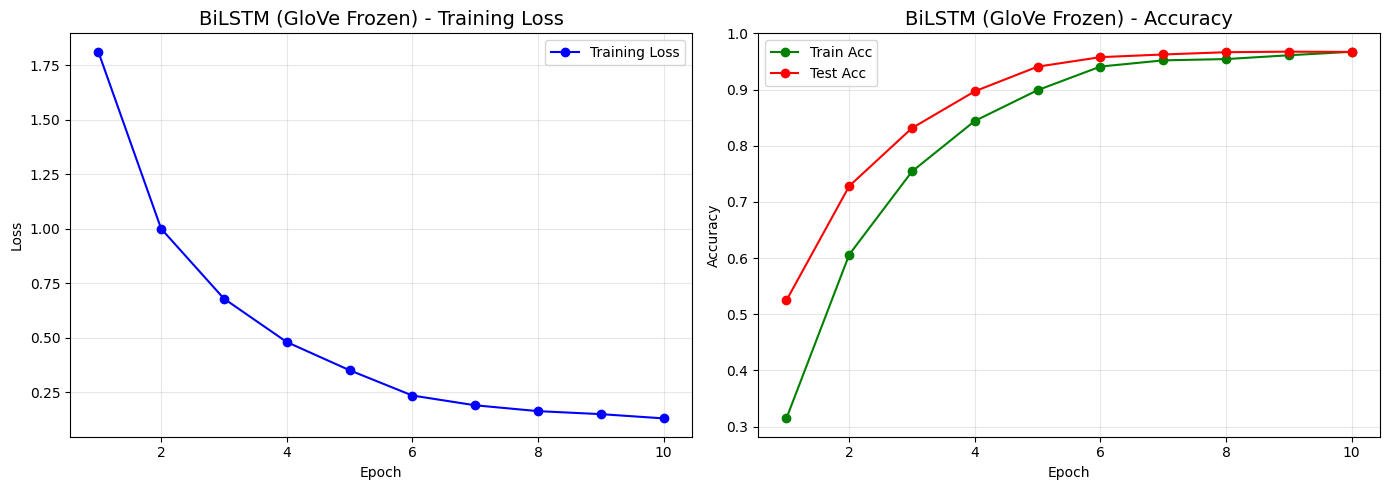

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS_RNN+1), rnn_train_losses, 'b-o', label='Training Loss')
axes[0].set_title('BiLSTM (GloVe Frozen) - Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS_RNN+1), rnn_train_accs, 'g-o', label='Train Acc')
axes[1].plot(range(1, EPOCHS_RNN+1), rnn_test_accs, 'r-o', label='Test Acc')
axes[1].set_title('BiLSTM (GloVe Frozen) - Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.9 - Evaluate BiLSTM


--- BiLSTM Final Evaluation ---
[DEBUG] Eval - tokens shape: torch.Size([64, 256])
[DEBUG] Eval - logits shape: torch.Size([64, 14])

BiLSTM RESULTS (GloVe Pretrained, Frozen Embeddings)
  Accuracy:   0.9671
  F1 (macro): 0.9671
  Precision:  0.9681
  Recall:     0.9671

[INFO] Per-class report:
                        precision    recall  f1-score   support

               Company     0.9444    0.9067    0.9252       300
EducationalInstitution     0.9583    0.9967    0.9771       300
                Artist     0.9668    0.9700    0.9684       300
               Athlete     0.9803    0.9933    0.9868       300
          OfficeHolder     0.9862    0.9533    0.9695       300
  MeanOfTransportation     0.9704    0.9833    0.9768       300
              Building     0.9893    0.9233    0.9552       300
          NaturalPlace     0.9583    0.9967    0.9771       300
               Village     0.9900    0.9900    0.9900       300
                Animal     0.8862    0.9867    0.9338       3

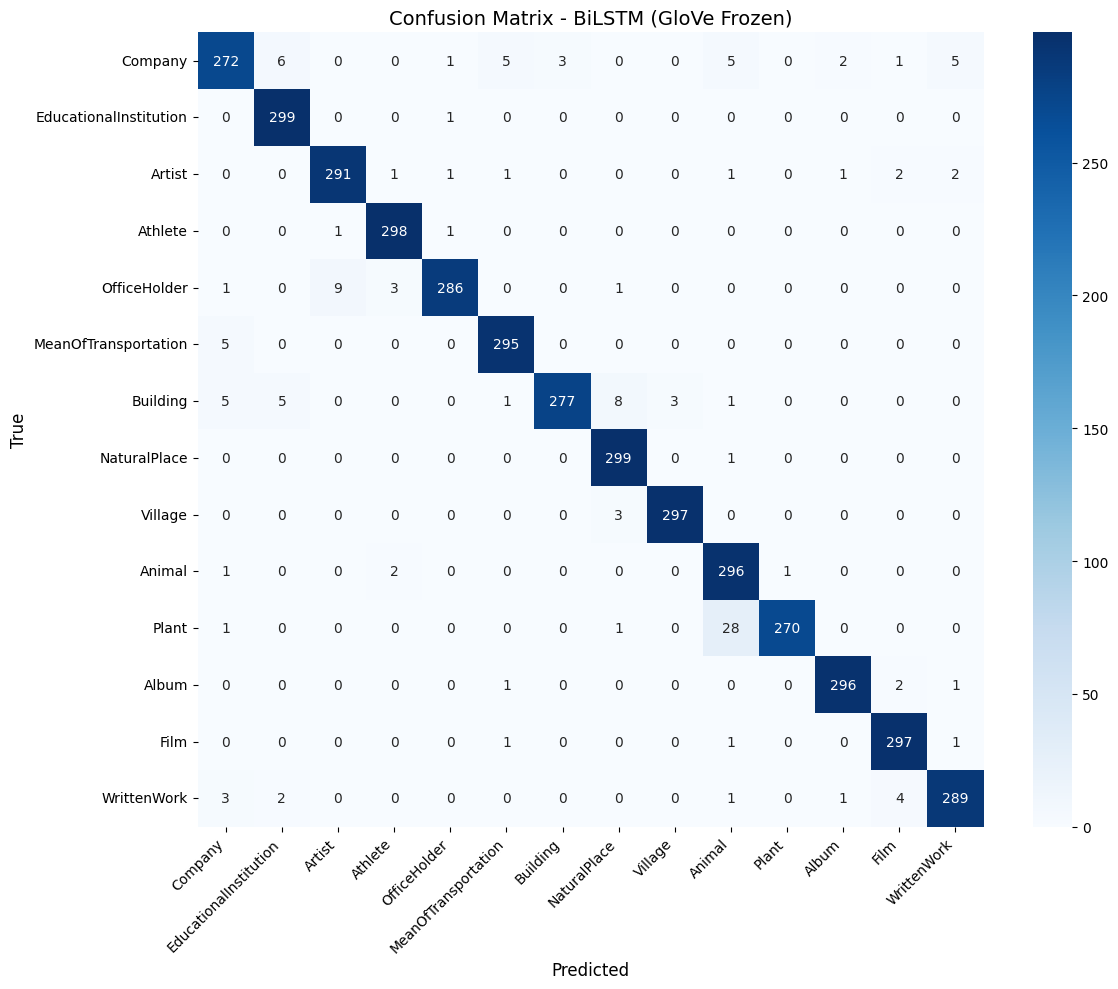

In [ ]:
print("\n--- BiLSTM Final Evaluation ---")

bilstm_model.eval()
rnn_preds = []
rnn_true = []

with torch.no_grad():
    for batch_idx, (tokens, labels) in enumerate(test_loader_rnn):
        tokens = tokens.to(device)
        logits = bilstm_model(tokens)

        if batch_idx == 0:
            print(f"[DEBUG] Eval - tokens shape: {tokens.shape}")
            print(f"[DEBUG] Eval - logits shape: {logits.shape}")

        _, predicted = logits.max(1)
        rnn_preds.extend(predicted.cpu().numpy().tolist())
        rnn_true.extend(labels.numpy().tolist())

rnn_acc = accuracy_score(rnn_true, rnn_preds)
rnn_f1 = f1_score(rnn_true, rnn_preds, average='macro')
rnn_precision = precision_score(rnn_true, rnn_preds, average='macro')
rnn_recall = recall_score(rnn_true, rnn_preds, average='macro')

print(f"\n{'='*50}")
print(f"BiLSTM RESULTS (GloVe Pretrained, Frozen Embeddings)")
print(f"{'='*50}")
print(f"  Accuracy:   {rnn_acc:.4f}")
print(f"  F1 (macro): {rnn_f1:.4f}")
print(f"  Precision:  {rnn_precision:.4f}")
print(f"  Recall:     {rnn_recall:.4f}")

print(f"\n[INFO] Per-class report:")
print(classification_report(rnn_true, rnn_preds,
                             target_names=CLASS_NAMES, digits=4))

cm_rnn = confusion_matrix(rnn_true, rnn_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - BiLSTM (GloVe Frozen)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 4 - Model 2: BERT with Frozen Backbone
```
PRINCIPLE:
  Linear Probing — evaluate the quality of pretrained representations.
  The entire BERT backbone (12 transformer layers, 110M params) is FROZEN.
  Only a single Linear(768, 14) classification head is trained.
  This tests: "How good are BERT's representations out-of-the-box?"

WHAT IS FROZEN vs TRAINED:
  FROZEN:  All 12 transformer layers + embeddings (~109M params, ~99.9%)
  TRAINED: Only classifier.weight and classifier.bias (~10K params, ~0.01%)
```

```
ARCHITECTURE:
  Input text → BERT Tokenizer (WordPiece, max_len=256)
      ↓
  [1] BERT Backbone (bert-base-uncased, FROZEN)
      - Token Embeddings + Position Embeddings + Segment Embeddings
      - 12 Transformer Encoder layers, each with:
        * Multi-Head Self-Attention (12 heads)
          Attention(Q,K,V) = softmax(QK^T / √d_k) × V
        * Feed-Forward Network (768 → 3072 → 768)
        * Layer Normalization + Residual Connections
      - [CLS] token embedding used for classification
      ↓
  [2] Classification Head: Linear(768, 14) (TRAINED)
      ↓
  Output: logits for 14 classes
```

## 4.1 - Tokenize

In [ ]:
print("\n[INFO] Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print(f"[INFO] BERT vocab size: {bert_tokenizer.vocab_size}")

MAX_LEN_BERT = 256

print(f"\n[INFO] Tokenizing with BERT tokenizer (max_len={MAX_LEN_BERT})...")

train_texts = df_train['processed_text'].tolist()
test_texts = df_test['processed_text'].tolist()

train_encoding = bert_tokenizer(
    train_texts, padding='max_length', truncation=True,
    max_length=MAX_LEN_BERT, return_tensors='pt'
)
test_encoding = bert_tokenizer(
    test_texts, padding='max_length', truncation=True,
    max_length=MAX_LEN_BERT, return_tensors='pt'
)

print(f"\n[DEBUG] Train input_ids shape: {train_encoding['input_ids'].shape}")
print(f"[DEBUG] Train attention_mask shape: {train_encoding['attention_mask'].shape}")
print(f"[DEBUG] Test input_ids shape: {test_encoding['input_ids'].shape}")
print(f"[DEBUG] Decoded sample: {bert_tokenizer.decode(train_encoding['input_ids'][0][:30])}")



[INFO] Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[INFO] BERT vocab size: 30522

[INFO] Tokenizing with BERT tokenizer (max_len=256)...

[DEBUG] Train input_ids shape: torch.Size([14000, 256])
[DEBUG] Train attention_mask shape: torch.Size([14000, 256])
[DEBUG] Test input_ids shape: torch.Size([4200, 256])
[DEBUG] Decoded sample: [CLS] eucalyptus porosa is a species of eucalypt or gum tree native to southern australia common names include black mallee black mallee box quo


## 4.2 - DataLoader

In [ ]:
class BERTDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }


BATCH_SIZE_BERT = 16

train_dataset_bert = BERTDataset(train_encoding, train_labels)
test_dataset_bert = BERTDataset(test_encoding, test_labels)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=BATCH_SIZE_BERT,
                                shuffle=True, drop_last=False)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=BATCH_SIZE_BERT, shuffle=False)

print(f"\n[INFO] BERT DataLoader:")
print(f"  Train batches: {len(train_loader_bert)}")
print(f"  Test batches: {len(test_loader_bert)}")
print(f"  Batch size: {BATCH_SIZE_BERT}")



[INFO] BERT DataLoader:
  Train batches: 875
  Test batches: 263
  Batch size: 16


## 4.3 - Load BERT and FREEZE backbone
```
KEY DESIGN DECISIONS:
  - Freezing ALL BERT layers (not just some) = pure linear probing
  - BertForSequenceClassification: includes the [CLS] → classifier head
  - Batch size 16 (vs 64 for BiLSTM): BERT needs more GPU memory
  - Higher LR than fine-tuning: training a fresh layer, not adjusting pretrained weights
```

In [ ]:
print("\n[INFO] Loading BERT model...")
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_CLASSES
)
bert_model = bert_model.to(device)

# FREEZE ALL BERT backbone layers, keep only classifier trainable
for name, param in bert_model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

total_params_bert = sum(p.numel() for p in bert_model.parameters())
trainable_params_bert = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
frozen_params_bert = total_params_bert - trainable_params_bert

print(f"\n[INFO] BERT Model loaded!")
print(f"[INFO] Total parameters: {total_params_bert:,}")
print(f"[INFO] Trainable parameters: {trainable_params_bert:,} (classifier head only)")
print(f"[INFO] Frozen parameters: {frozen_params_bert:,} (BERT backbone)")
print(f"[INFO] Frozen ratio: {frozen_params_bert/total_params_bert*100:.1f}%")

print(f"\n[INFO] Trainable layers:")
for name, param in bert_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.shape}")



[INFO] Loading BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[INFO] BERT Model loaded!
[INFO] Total parameters: 109,493,006
[INFO] Trainable parameters: 10,766 (classifier head only)
[INFO] Frozen parameters: 109,482,240 (BERT backbone)
[INFO] Frozen ratio: 100.0%

[INFO] Trainable layers:
  classifier.weight: torch.Size([14, 768])
  classifier.bias: torch.Size([14])


## 4.4 - Train BERT (classifier head only)
```
TRAINING CONFIG:
  - Optimizer: Adam (only classifier head params)
  - Learning Rate: 1e-2 (NOT 2e-5)
    WHY 1e-2? Because we're training a NEW random linear layer,
    not fine-tuning existing BERT weights. Higher LR is appropriate.
  - Scheduler: StepLR (step=5, gamma=0.5)
  - Epochs: 10
  - Gradient Clipping: max_norm=1.0
  - Batch Size: 16 (smaller due to BERT's memory usage)
```

In [ ]:
print("\n--- Training BERT (Backbone Frozen, Classifier Head Only) ---")

EPOCHS_BERT = 10
LR_BERT = 1e-2
WARMUP_STEPS = len(train_loader_bert) // 3

# Only optimize trainable params (classifier head)
optimizer_bert = optim.Adam(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=LR_BERT
)
total_steps = len(train_loader_bert) * EPOCHS_BERT
scheduler_bert = optim.lr_scheduler.StepLR(optimizer_bert, step_size=5, gamma=0.5)

print(f"\n[INFO] BERT training hyperparameters:")
print(f"  Epochs: {EPOCHS_BERT}")
print(f"  Learning rate: {LR_BERT}")
print(f"  Total steps: {total_steps}")
print(f"  Optimizer: Adam (classifier head only)")
print(f"  Scheduler: StepLR (step=5, gamma=0.5)")
print(f"  NOTE: BERT backbone FROZEN. LR=1e-2 is appropriate for linear probing")
print(f"         (much higher than fine-tuning LR of 2e-5 because we train a")
print(f"          new random linear layer, not pre-existing BERT weights)")

bert_train_losses = []
bert_train_accs = []
bert_test_accs = []

for epoch in range(EPOCHS_BERT):
    bert_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(tqdm(train_loader_bert,
                                            desc=f"BERT Epoch {epoch+1}/{EPOCHS_BERT}")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        if epoch == 0 and batch_idx == 0:
            print(f"\n  [DEBUG] input_ids shape: {input_ids.shape}")
            print(f"  [DEBUG] attention_mask shape: {attention_mask.shape}")
            print(f"  [DEBUG] labels shape: {labels.shape}")

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask,
                              labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        if epoch == 0 and batch_idx == 0:
            print(f"  [DEBUG] BERT logits shape: {logits.shape}")
            print(f"  [DEBUG] BERT loss: {loss.item():.4f}")
            # Verify backbone is frozen
            for name, param in bert_model.named_parameters():
                if 'bert.embeddings' in name:
                    print(f"  [DEBUG] {name} requires_grad: {param.requires_grad}")
                    break

        optimizer_bert.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer_bert.step()

        running_loss += loss.item() * input_ids.size(0)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    bert_train_losses.append(epoch_loss)
    bert_train_accs.append(epoch_acc)

    # Test evaluation
    bert_model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch in test_loader_bert:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            _, predicted = outputs.logits.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
    test_acc = test_correct / test_total
    bert_test_accs.append(test_acc)

    scheduler_bert.step()

    print(f"  Epoch [{epoch+1}/{EPOCHS_BERT}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Test Acc: {test_acc:.4f} | "
          f"LR: {scheduler_bert.get_last_lr()[0]:.6f}")



--- Training BERT (Backbone Frozen, Classifier Head Only) ---

[INFO] BERT training hyperparameters:
  Epochs: 10
  Learning rate: 0.01
  Total steps: 8750
  Optimizer: Adam (classifier head only)
  Scheduler: StepLR (step=5, gamma=0.5)
  NOTE: BERT backbone FROZEN. LR=1e-2 is appropriate for linear probing
         (much higher than fine-tuning LR of 2e-5 because we train a
          new random linear layer, not pre-existing BERT weights)


BERT Epoch 1/10:   0%|          | 0/875 [00:00<?, ?it/s]


  [DEBUG] input_ids shape: torch.Size([16, 256])
  [DEBUG] attention_mask shape: torch.Size([16, 256])
  [DEBUG] labels shape: torch.Size([16])


BERT Epoch 1/10:   0%|          | 3/875 [00:00<01:31,  9.51it/s]

  [DEBUG] BERT logits shape: torch.Size([16, 14])
  [DEBUG] BERT loss: 2.7060
  [DEBUG] bert.embeddings.word_embeddings.weight requires_grad: False


...

  Epoch [8/10] Loss: 0.4367 | Train Acc: 0.8969 | Test Acc: 0.9238 | LR: 0.005000


BERT Epoch 9/10: 100%|██████████| 875/875 [00:43<00:00, 20.09it/s]


  Epoch [9/10] Loss: 0.4200 | Train Acc: 0.8970 | Test Acc: 0.9276 | LR: 0.005000


BERT Epoch 10/10: 100%|██████████| 875/875 [00:43<00:00, 20.07it/s]


  Epoch [10/10] Loss: 0.4230 | Train Acc: 0.8996 | Test Acc: 0.9333 | LR: 0.002500


## 4.5 - Plot Curves


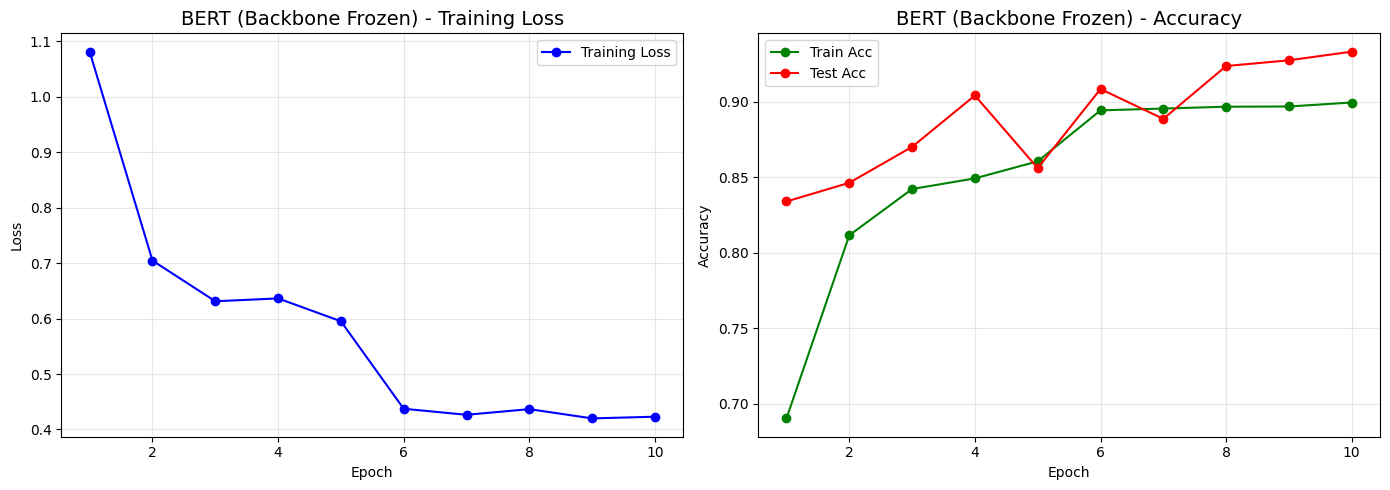

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS_BERT+1), bert_train_losses, 'b-o', label='Training Loss')
axes[0].set_title('BERT (Backbone Frozen) - Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS_BERT+1), bert_train_accs, 'g-o', label='Train Acc')
axes[1].plot(range(1, EPOCHS_BERT+1), bert_test_accs, 'r-o', label='Test Acc')
axes[1].set_title('BERT (Backbone Frozen) - Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 - Evaluate BERT


--- BERT Final Evaluation ---
[DEBUG] Eval - input_ids shape: torch.Size([16, 256])
[DEBUG] Eval - logits shape: torch.Size([16, 14])

BERT RESULTS (Backbone Frozen, Classifier Trained)
  Accuracy:   0.9333
  F1 (macro): 0.9324
  Precision:  0.9369
  Recall:     0.9333

[INFO] Per-class report:
                        precision    recall  f1-score   support

               Company     0.9657    0.7500    0.8443       300
EducationalInstitution     0.9383    0.9633    0.9507       300
                Artist     0.9498    0.8833    0.9154       300
               Athlete     0.9832    0.9733    0.9782       300
          OfficeHolder     0.9443    0.9600    0.9521       300
  MeanOfTransportation     0.9542    0.9733    0.9637       300
              Building     0.8427    0.9467    0.8917       300
          NaturalPlace     0.9379    0.9567    0.9472       300
               Village     1.0000    0.9433    0.9708       300
                Animal     0.9429    0.9900    0.9659       30

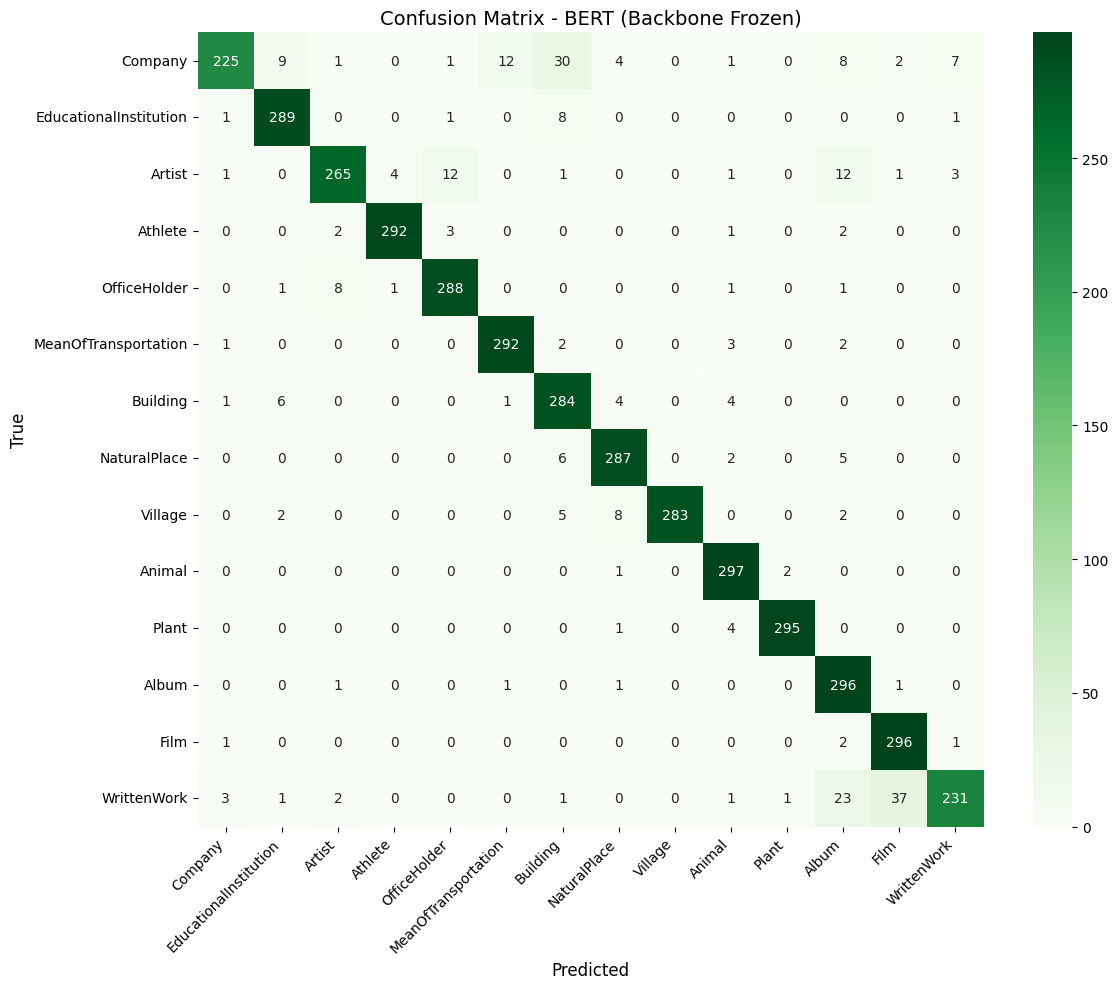

In [ ]:
print("\n--- BERT Final Evaluation ---")

bert_model.eval()
bert_preds = []
bert_true = []

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader_bert):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        if batch_idx == 0:
            print(f"[DEBUG] Eval - input_ids shape: {input_ids.shape}")
            print(f"[DEBUG] Eval - logits shape: {logits.shape}")

        _, predicted = logits.max(1)
        bert_preds.extend(predicted.cpu().numpy().tolist())
        bert_true.extend(labels.numpy().tolist())

bert_acc = accuracy_score(bert_true, bert_preds)
bert_f1 = f1_score(bert_true, bert_preds, average='macro')
bert_precision = precision_score(bert_true, bert_preds, average='macro')
bert_recall = recall_score(bert_true, bert_preds, average='macro')

print(f"\n{'='*50}")
print(f"BERT RESULTS (Backbone Frozen, Classifier Trained)")
print(f"{'='*50}")
print(f"  Accuracy:   {bert_acc:.4f}")
print(f"  F1 (macro): {bert_f1:.4f}")
print(f"  Precision:  {bert_precision:.4f}")
print(f"  Recall:     {bert_recall:.4f}")

print(f"\n[INFO] Per-class report:")
print(classification_report(bert_true, bert_preds,
                             target_names=CLASS_NAMES, digits=4))

cm_bert = confusion_matrix(bert_true, bert_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - BERT (Backbone Frozen)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 5 - Comparison: BiLSTM (GloVe) vs BERT (Frozen)
```
CORE COMPARISON:

  Feature                    BiLSTM (GloVe)         BERT (Frozen)
  ─────────────────────────────────────────────────────────────────
  Pretrained Component       GloVe 6B 100d          BERT-base-uncased
  Embedding Type             Static (word-level)    Contextual (subword)
  Frozen Params              Embedding only         All 12 layers
  Trained Params             LSTM + FC heads        Linear head only
  Sequence Processing        Sequential (O(n))      Parallel (O(1) hops)
  Context Window             Limited by LSTM decay  Full (self-attention)
```

## 5.1 - Summary Table

In [ ]:
comparison_data = {
    'Metric': ['Accuracy', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)',
               'Total Parameters', 'Trainable Parameters', 'Frozen Parameters',
               'Training Epochs', 'Pretrained Component', 'Architecture'],
    'BiLSTM (GloVe Frozen)': [
        f"{rnn_acc:.4f}", f"{rnn_f1:.4f}", f"{rnn_precision:.4f}",
        f"{rnn_recall:.4f}", f"{total_params_rnn:,}", f"{trainable_params_rnn:,}",
        f"{frozen_params_rnn:,}", str(EPOCHS_RNN),
        'GloVe 6B 100d', 'GloVe(frozen) + BiLSTM + FC'
    ],
    'BERT (Backbone Frozen)': [
        f"{bert_acc:.4f}", f"{bert_f1:.4f}", f"{bert_precision:.4f}",
        f"{bert_recall:.4f}", f"{total_params_bert:,}", f"{trainable_params_bert:,}",
        f"{frozen_params_bert:,}", str(EPOCHS_BERT),
        'BERT-base-uncased', 'BERT(frozen) + Linear'
    ]
}
df_comparison = pd.DataFrame(comparison_data)
print("\n[RESULTS] Comparison Table:")
print(df_comparison.to_string(index=False))



[RESULTS] Comparison Table:
              Metric       BiLSTM (GloVe Frozen) BERT (Backbone Frozen)
            Accuracy                      0.9671                 0.9333
          F1 (macro)                      0.9671                 0.9324
   Precision (macro)                      0.9681                 0.9369
      Recall (macro)                      0.9671                 0.9333
    Total Parameters                   3,191,486            109,493,006
Trainable Parameters                     665,486                 10,766
   Frozen Parameters                   2,526,000            109,482,240
     Training Epochs                          10                     10
Pretrained Component               GloVe 6B 100d      BERT-base-uncased
        Architecture GloVe(frozen) + BiLSTM + FC  BERT(frozen) + Linear


## 5.2 - Visualization

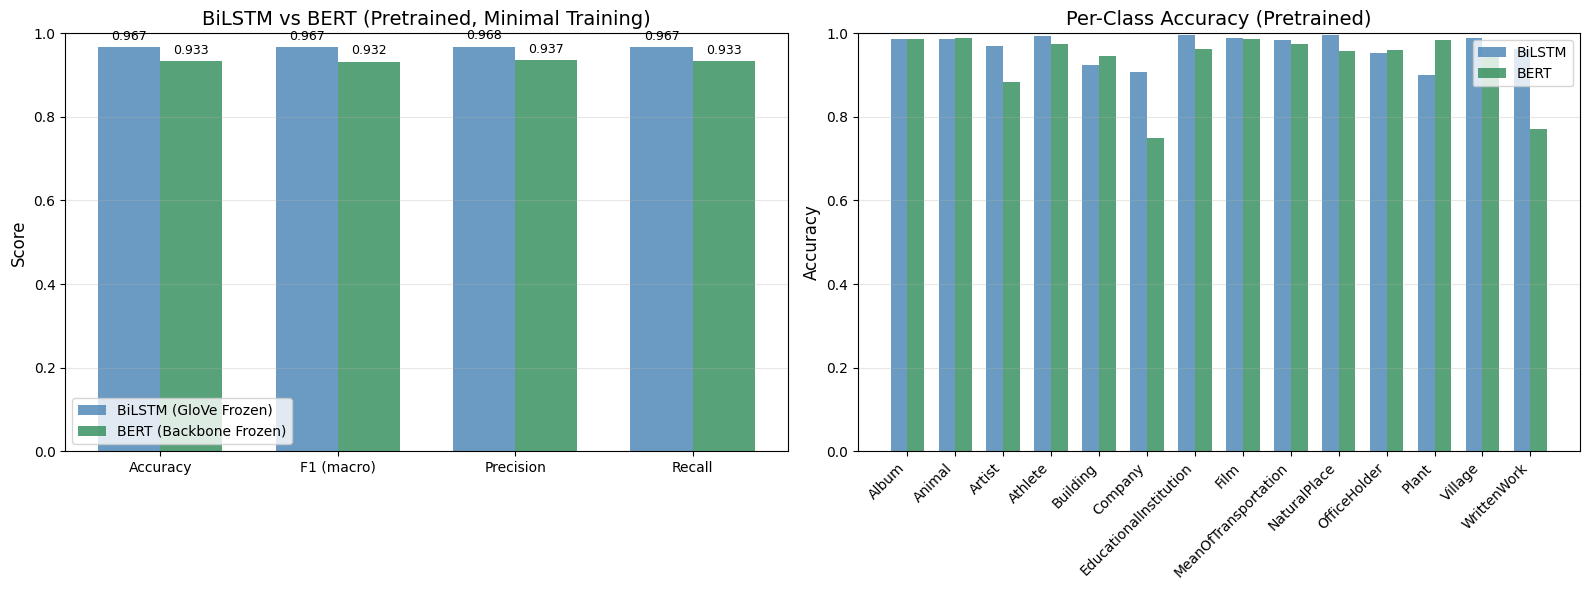

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
rnn_scores = [rnn_acc, rnn_f1, rnn_precision, rnn_recall]
bert_scores = [bert_acc, bert_f1, bert_precision, bert_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, rnn_scores, width,
                     label='BiLSTM (GloVe Frozen)', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, bert_scores, width,
                     label='BERT (Backbone Frozen)', color='seagreen', alpha=0.8)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('BiLSTM vs BERT (Pretrained, Minimal Training)', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

# Per-class accuracy
rnn_per_class = {}
bert_per_class = {}
for i, cls_name in enumerate(CLASS_NAMES):
    rnn_mask = np.array(rnn_true) == i
    if rnn_mask.sum() > 0:
        rnn_per_class[cls_name] = (np.array(rnn_preds)[rnn_mask] == i).mean()
    bert_mask = np.array(bert_true) == i
    if bert_mask.sum() > 0:
        bert_per_class[cls_name] = (np.array(bert_preds)[bert_mask] == i).mean()

shared = sorted(set(rnn_per_class) & set(bert_per_class))
x2 = np.arange(len(shared))

axes[1].bar(x2 - width/2, [rnn_per_class[c] for c in shared],
            width, label='BiLSTM', color='steelblue', alpha=0.8)
axes[1].bar(x2 + width/2, [bert_per_class[c] for c in shared],
            width, label='BERT', color='seagreen', alpha=0.8)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Per-Class Accuracy (Pretrained)', fontsize=14)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(shared, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# 6 - Analysis and Discussion

In [ ]:
print(f"""
Key Findings (Pretrained Models):
===================================

1. BiLSTM with Pretrained GloVe (Frozen Embeddings):
   - Accuracy: {rnn_acc:.4f}
   - Architecture: GloVe(frozen) + BiLSTM({EMBED_DIM},{HIDDEN_DIM},layers={NUM_LAYERS}) + FC
   - Total params: {total_params_rnn:,}
   - Trainable: {trainable_params_rnn:,} | Frozen: {frozen_params_rnn:,}
   - Pretrained: GloVe 6B 100d (word-level embeddings)
   - Training: {EPOCHS_RNN} epochs, only LSTM + FC layers
   - The embedding layer is NOT trained (uses pretrained GloVe)

2. BERT with Frozen Backbone (Linear Probing):
   - Accuracy: {bert_acc:.4f}
   - Architecture: BERT-base(frozen) + Linear(768, {NUM_CLASSES})
   - Total params: {total_params_bert:,}
   - Trainable: {trainable_params_bert:,} | Frozen: {frozen_params_bert:,}
   - Pretrained: BERT-base-uncased (12 layers, 768 hidden)
   - Training: {EPOCHS_BERT} epochs, only classification head
   - All 12 transformer layers are FROZEN

3. Comparison:
   - {'BERT outperforms BiLSTM' if bert_acc > rnn_acc else 'BiLSTM outperforms BERT'}
   - Accuracy difference: {abs(bert_acc - rnn_acc):.4f}
   - BERT trains only {trainable_params_bert:,} params vs BiLSTM's {trainable_params_rnn:,}
   - Both leverage pretrained knowledge (transfer learning)

4. Difference from Training Version (text_classification.py):
   - Training version BiLSTM: ALL layers trained from scratch
     -> This version: GloVe embeddings FROZEN, only LSTM+FC trained
   - Training version BERT: ALL 109M params fine-tuned
     -> This version: Backbone FROZEN, only {trainable_params_bert:,} params trained

5. Deep Learning Principles:
   - Transfer Learning: Reusing pretrained representations
   - Linear Probing: Evaluating pretrained feature quality
   - Frozen vs Fine-tuned: Trade-off between efficiency and performance
   - RNN/LSTM: Sequential processing with gating mechanisms
   - Transformer: Self-attention for parallel context capture
   - Pretrained Embeddings: GloVe (static) vs BERT (contextual)

6. Dataset:
   - DBpedia-14: {NUM_CLASSES} classes, Wikipedia articles
   - Training: {len(df_train)} samples, Test: {len(df_test)} samples
   - Balanced: {TRAIN_SAMPLES_PER_CLASS} per class
""")



Key Findings (Pretrained Models):

1. BiLSTM with Pretrained GloVe (Frozen Embeddings):
   - Accuracy: 0.9671
   - Architecture: GloVe(frozen) + BiLSTM(100,128,layers=2) + FC
   - Total params: 3,191,486
   - Trainable: 665,486 | Frozen: 2,526,000
   - Pretrained: GloVe 6B 100d (word-level embeddings)
   - Training: 10 epochs, only LSTM + FC layers
   - The embedding layer is NOT trained (uses pretrained GloVe)

2. BERT with Frozen Backbone (Linear Probing):
   - Accuracy: 0.9333
   - Architecture: BERT-base(frozen) + Linear(768, 14)
   - Total params: 109,493,006
   - Trainable: 10,766 | Frozen: 109,482,240
   - Pretrained: BERT-base-uncased (12 layers, 768 hidden)
   - Training: 10 epochs, only classification head
   - All 12 transformer layers are FROZEN

3. Comparison:
   - BiLSTM outperforms BERT
   - Accuracy difference: 0.0338
   - BERT trains only 10,766 params vs BiLSTM's 665,486
   - Both leverage pretrained knowledge (transfer learning)

4. Difference from Training Version 

# 7 - EXTENSION 1: Advanced Embedding Visualization (t-SNE / PCA)

```
PRINCIPLE:
  Visualize how well BERT's PRETRAINED [CLS] embeddings separate the 14
  classes BEFORE any training. This shows the quality of pretrained features.

METHOD:
  1. Extract [CLS] embeddings from a fresh BertModel (not the trained one)
  2. PCA: 768d → 50d (dimensionality reduction, preserves variance)
  3. t-SNE: 50d → 2d (non-linear projection to visualize clusters)
     - Perplexity=30, n_iter=1000 (controls neighborhood size)

INSIGHT:
  - Even WITHOUT fine-tuning, BERT embeddings show semantic clustering
  - Well-separated clusters (Village, Plant, Animal) → easy to classify
  - Overlapping clusters (Artist, Athlete, OfficeHolder) → harder
  - Cluster separation degree predicts per-class accuracy
```

[INFO] Extracting BERT [CLS] embeddings for t-SNE visualization...
[INFO] This shows how well BERT's pretrained representations
       separate DBpedia classes BEFORE any fine-tuning.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] Extracting embeddings for 1400 samples...


Extracting [CLS]: 100%|██████████| 44/44 [00:02<00:00, 17.42it/s]


[DEBUG] Embeddings shape: (1400, 768)
[INFO] Running PCA (768d -> 50d) then t-SNE (50d -> 2d)...
[DEBUG] PCA explained variance ratio (first 5): [0.2164 0.0432 0.0379 0.0339 0.0293]
[DEBUG] PCA total explained variance (50 components): 0.7294


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[DEBUG] t-SNE output shape: (1400, 2)


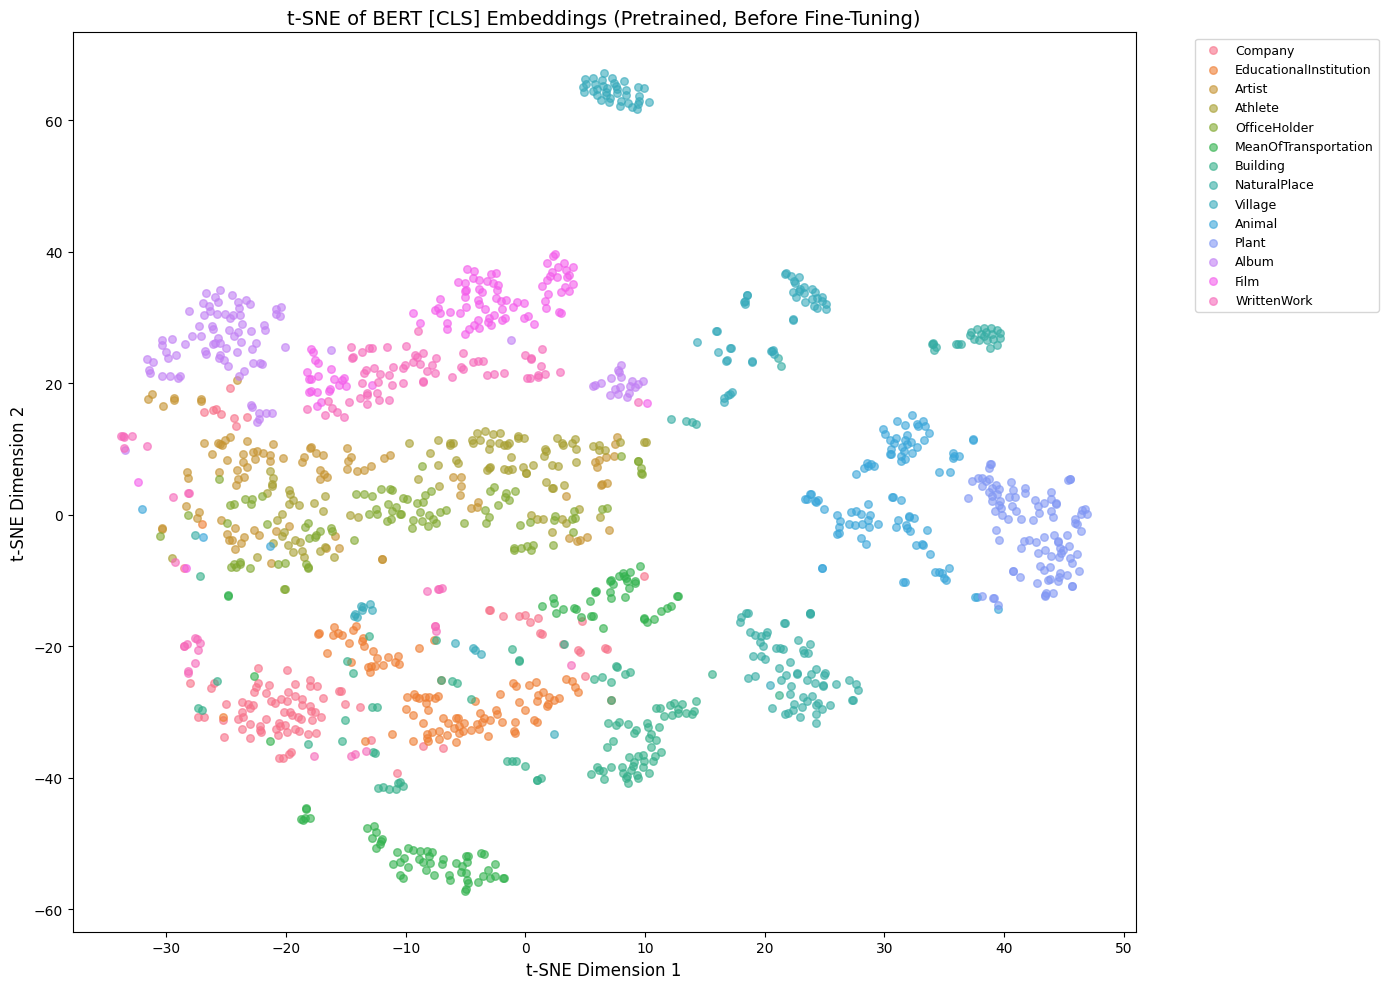


[ANALYSIS] t-SNE Visualization Insights:
  - Even WITHOUT fine-tuning, BERT's [CLS] embeddings show semantic clustering
  - Categories like Village, Plant, Animal form distinct clusters
  - Categories like Artist, Athlete, OfficeHolder overlap (all describe people)
  - This demonstrates BERT's pretrained knowledge of entity types
  - The DEGREE of cluster separation predicts classification difficulty
  - Well-separated clusters -> high accuracy (Village, Plant)
  - Overlapping clusters -> lower accuracy (Artist vs OfficeHolder)



In [ ]:
print("[INFO] Extracting BERT [CLS] embeddings for t-SNE visualization...")
print("[INFO] This shows how well BERT's pretrained representations")
print("       separate DBpedia classes BEFORE any fine-tuning.")

# Load a fresh BertModel (not fine-tuned) for embedding extraction
bert_base = BertModel.from_pretrained('bert-base-uncased', attn_implementation='eager')
bert_base = bert_base.to(device)
bert_base.eval()
for param in bert_base.parameters():
    param.requires_grad = False

# Extract [CLS] embeddings for a subset of training data
TSNE_SAMPLES_PER_CLASS = 100
tsne_indices = []
for label in range(NUM_CLASSES):
    cls_idx = df_train[df_train['label'] == label].index.tolist()
    tsne_indices.extend(cls_idx[:TSNE_SAMPLES_PER_CLASS])

tsne_texts = [df_train.loc[i, 'processed_text'] for i in tsne_indices]
tsne_labels = [df_train.loc[i, 'label'] for i in tsne_indices]
tsne_categories = [CLASS_NAMES[l] for l in tsne_labels]

print(f"[INFO] Extracting embeddings for {len(tsne_texts)} samples...")

tsne_embeddings = []
for i in tqdm(range(0, len(tsne_texts), 32), desc="Extracting [CLS]"):
    batch = tsne_texts[i:i+32]
    enc = bert_tokenizer(batch, padding='max_length', truncation=True,
                         max_length=128, return_tensors='pt')
    with torch.no_grad():
        out = bert_base(input_ids=enc['input_ids'].to(device),
                        attention_mask=enc['attention_mask'].to(device))
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        tsne_embeddings.append(cls_emb)

tsne_embeddings = np.concatenate(tsne_embeddings, axis=0)
print(f"[DEBUG] Embeddings shape: {tsne_embeddings.shape}")

# Run PCA first (for dimensionality reduction before t-SNE)
print("[INFO] Running PCA (768d -> 50d) then t-SNE (50d -> 2d)...")
pca = PCA(n_components=50, random_state=SEED)
embeddings_pca = pca.fit_transform(tsne_embeddings)
print(f"[DEBUG] PCA explained variance ratio (first 5): {pca.explained_variance_ratio_[:5].round(4)}")
print(f"[DEBUG] PCA total explained variance (50 components): {pca.explained_variance_ratio_.sum():.4f}")

# Run t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_pca)
print(f"[DEBUG] t-SNE output shape: {embeddings_2d.shape}")

# Plot t-SNE
plt.figure(figsize=(14, 10))
palette = sns.color_palette("husl", NUM_CLASSES)
for i, cls_name in enumerate(CLASS_NAMES):
    mask = np.array(tsne_labels) == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[palette[i]], label=cls_name, alpha=0.6, s=30)

plt.title('t-SNE of BERT [CLS] Embeddings (Pretrained, Before Fine-Tuning)',
          fontsize=14)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("""
[ANALYSIS] t-SNE Visualization Insights:
  - Even WITHOUT fine-tuning, BERT's [CLS] embeddings show semantic clustering
  - Categories like Village, Plant, Animal form distinct clusters
  - Categories like Artist, Athlete, OfficeHolder overlap (all describe people)
  - This demonstrates BERT's pretrained knowledge of entity types
  - The DEGREE of cluster separation predicts classification difficulty
  - Well-separated clusters -> high accuracy (Village, Plant)
  - Overlapping clusters -> lower accuracy (Artist vs OfficeHolder)
""")

# Free memory
del bert_base
torch.cuda.empty_cache() if torch.cuda.is_available() else None


# 8 - EXTENSION 2: Text Data Augmentation

```
PRINCIPLE:
  Increase training data diversity to improve robustness WITHOUT collecting
  new data. Unlike image augmentation (flip, rotate), text augmentation
  must preserve semantic meaning while creating lexical variation.

TECHNIQUES:
  1. SYNONYM REPLACEMENT: Replace words with WordNet synonyms
     "The cat sat on the mat" → "The feline sat on the rug"
     - Preserves meaning, changes surface form
     - Only replaces words that have synonyms in WordNet

  2. RANDOM DELETION: Remove random words with probability p=0.15
     "The cat sat on the mat" → "cat sat the mat"
     - Forces model to be robust to incomplete information
     - Always keeps at least one word

  3. COMBINED: Apply both synonym replacement AND random deletion
     - Provides both types of variation simultaneously

INSIGHT:
  - Augmentation is especially important for low-resource scenarios
  - Creates lexical diversity without changing the label
  - In production, augmented data would be added to training set
```


## 8.1 - Augmentation

In [ ]:

import nltk
try:
    from nltk.corpus import wordnet
    wordnet.synsets('test')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    from nltk.corpus import wordnet

print("[INFO] NLTK WordNet loaded for synonym replacement.")


def synonym_replacement(text, n_replacements=3):
    """
    Replace n random words with their WordNet synonyms.
    Only replaces content words (nouns, verbs, adjectives).
    """
    words = text.split()
    if len(words) < 3:
        return text

    new_words = words.copy()
    # Candidates: words with synonyms
    candidates = []
    for i, word in enumerate(words):
        syns = wordnet.synsets(word)
        if syns:
            candidates.append((i, word, syns))

    random.shuffle(candidates)
    replaced = 0

    for idx, word, syns in candidates:
        if replaced >= n_replacements:
            break
        # Get all lemmas from all synsets
        synonyms = set()
        for syn in syns:
            for lemma in syn.lemmas():
                if lemma.name() != word and '_' not in lemma.name():
                    synonyms.add(lemma.name())
        if synonyms:
            new_words[idx] = random.choice(list(synonyms))
            replaced += 1

    return ' '.join(new_words)


def random_deletion(text, p=0.1):
    """
    Randomly delete words with probability p.
    Always keeps at least one word.
    """
    words = text.split()
    if len(words) <= 1:
        return text
    remaining = [w for w in words if random.random() > p]
    if len(remaining) == 0:
        return random.choice(words)
    return ' '.join(remaining)


def augment_text(text, method='synonym', n_aug=1):
    """
    Augment a text using the specified method.
    Returns a list of augmented texts.
    """
    augmented = []
    for _ in range(n_aug):
        if method == 'synonym':
            augmented.append(synonym_replacement(text, n_replacements=3))
        elif method == 'random_delete':
            augmented.append(random_deletion(text, p=0.15))
        elif method == 'both':
            t = synonym_replacement(text, n_replacements=2)
            t = random_deletion(t, p=0.1)
            augmented.append(t)
    return augmented


[INFO] NLTK WordNet loaded for synonym replacement.


## 8.2 - Demonstrate Augmentation

In [ ]:
print("\n--- Augmentation Examples ---")
print("Showing 3 original texts with their augmented versions:\n")

for i in range(3):
    original = df_train['processed_text'].iloc[i]
    category = df_train['category'].iloc[i]

    syn_aug = augment_text(original, method='synonym', n_aug=1)[0]
    del_aug = augment_text(original, method='random_delete', n_aug=1)[0]
    both_aug = augment_text(original, method='both', n_aug=1)[0]

    print(f"  [{category}] Sample {i+1}:")
    print(f"    Original:         {original[:100]}...")
    print(f"    Synonym Replace:  {syn_aug[:100]}...")
    print(f"    Random Delete:    {del_aug[:100]}...")
    print(f"    Combined (both):  {both_aug[:100]}...")
    print()



--- Augmentation Examples ---
Showing 3 original texts with their augmented versions:

  [Plant] Sample 1:
    Original:         eucalyptus porosa is a species of eucalypt or gum tree native to southern australia common names inc...
    Synonym Replace:  eucalyptus porosa is a species of eucalypt or gum tree native to southern australia common names inc...
    Random Delete:    eucalyptus porosa is a of eucalypt or gum tree native to southern australia common names include bla...
    Combined (both):  eucalyptus porosa a species of eucalypt or gum tree native to southern australia common names includ...

  [Plant] Sample 2:
    Original:         utricularia vulgaris common bladderwort is an aquatic species of bladderwort found in asia and europ...
    Synonym Replace:  utricularia vulgaris common bladderwort is an aquatic species of bladderwort found in asia and europ...
    Random Delete:    utricularia vulgaris common bladderwort is an aquatic of bladderwort found in asia and europe

## 8.3 - Augment training data

In [ ]:
print("[INFO] Augmenting training data (1 augmented copy per sample)...")

aug_texts = []
aug_labels = []
aug_categories = []

for idx in tqdm(range(len(df_train)), desc="Augmenting"):
    text = df_train['processed_text'].iloc[idx]
    label = df_train['label'].iloc[idx]
    category = df_train['category'].iloc[idx]

    aug = augment_text(text, method='both', n_aug=1)
    aug_texts.extend(aug)
    aug_labels.extend([label] * len(aug))
    aug_categories.extend([category] * len(aug))

print(f"\n[INFO] Original training samples: {len(df_train)}")
print(f"[INFO] Augmented samples created: {len(aug_texts)}")
print(f"[INFO] Total (original + augmented): {len(df_train) + len(aug_texts)}")

# Show augmented class distribution
aug_counter = Counter(aug_categories)
print(f"\n[INFO] Augmented samples per class:")
for cls in sorted(aug_counter.keys()):
    print(f"  {cls}: {aug_counter[cls]}")

print("""
[ANALYSIS] Text Augmentation Benefits:
  - Synonym Replacement: Creates lexical diversity without semantic shift
  - Random Deletion: Forces model to be robust to missing information
  - Combined: Provides both types of variation simultaneously
  - Augmentation is especially important for low-resource scenarios
  - In production, augmented data would be added to the training set
    to improve model generalization
""")

[INFO] Augmenting training data (1 augmented copy per sample)...


Augmenting: 100%|██████████| 14000/14000 [00:11<00:00, 1220.65it/s]


[INFO] Original training samples: 14000
[INFO] Augmented samples created: 14000
[INFO] Total (original + augmented): 28000

[INFO] Augmented samples per class:
  Album: 1000
  Animal: 1000
  Artist: 1000
  Athlete: 1000
  Building: 1000
  Company: 1000
  EducationalInstitution: 1000
  Film: 1000
  MeanOfTransportation: 1000
  NaturalPlace: 1000
  OfficeHolder: 1000
  Plant: 1000
  Village: 1000
  WrittenWork: 1000

[ANALYSIS] Text Augmentation Benefits:
  - Synonym Replacement: Creates lexical diversity without semantic shift
  - Random Deletion: Forces model to be robust to missing information
  - Combined: Provides both types of variation simultaneously
  - Augmentation is especially important for low-resource scenarios
  - In production, augmented data would be added to the training set
    to improve model generalization



# 9 - EXTENSION 3: BERT Attention Visualization

```
PRINCIPLE:
  Self-Attention weights reveal which input tokens the model considers
  most important for its classification decision. This provides
  interpretability — a key advantage of Transformers over RNNs.

METHOD:
  - Extract attention weights from the LAST BERT layer (closest to output)
  - BERT has 12 layers × 12 heads = 144 attention patterns
  - Average across all 12 heads in the final layer
  - Focus on [CLS] token row: [CLS] aggregates info for classification
  - Visualize as bar chart and full attention heatmap

  Formula: Attention(Q,K,V) = softmax(QK^T / √d_k) × V

INSIGHT:
  - For 'Album': high attention on "album", "released", "studio"
  - For 'Animal': high attention on species-related terms
  - For 'Athlete': high attention on "player", "born", sport terms
  - For 'Village': high attention on "village", "district", location terms
  - RNN hidden states are opaque (black-box)
  - Attention weights are explicitly interpretable as importance scores
```

## 9.1 - Attention

In [ ]:

def extract_attention_weights(text, tokenizer, model, device, max_len=128):
    """
    Extract self-attention weights from the final BERT layer for a single text.

    Returns:
      - tokens: list of token strings
      - attention: numpy array (seq_len, seq_len) - averaged across heads
      - cls_attention: numpy array (seq_len,) - [CLS] row of attention matrix
    """
    # Load a BertModel that outputs attentions
    encoding = tokenizer(text, padding='max_length', truncation=True,
                         max_length=max_len, return_tensors='pt')
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Get actual token length (before padding)
    actual_len = attention_mask.sum().item()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        output_attentions=True)

    # outputs.attentions is a tuple of (batch, heads, seq, seq) for each layer
    last_layer_attention = outputs.attentions[-1]  # (1, 12, seq, seq)

    # Average across all 12 heads
    avg_attention = last_layer_attention.mean(dim=1).squeeze(0)  # (seq, seq)
    avg_attention = avg_attention.cpu().numpy()

    # Get [CLS] token attention (row 0)
    cls_attention = avg_attention[0, :actual_len]  # (actual_len,)

    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().cpu())[:actual_len]

    return tokens, avg_attention[:actual_len, :actual_len], cls_attention


# Load BertModel for attention extraction (separate from classifier)
print("[INFO] Loading BertModel for attention extraction...")
bert_attention_model = BertModel.from_pretrained('bert-base-uncased', attn_implementation='eager')
bert_attention_model = bert_attention_model.to(device)
bert_attention_model.eval()
for param in bert_attention_model.parameters():
    param.requires_grad = False

[INFO] Loading BertModel for attention extraction...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 9.2 - Visualize attention for representative samples



--- Attention Visualization for Representative Samples ---


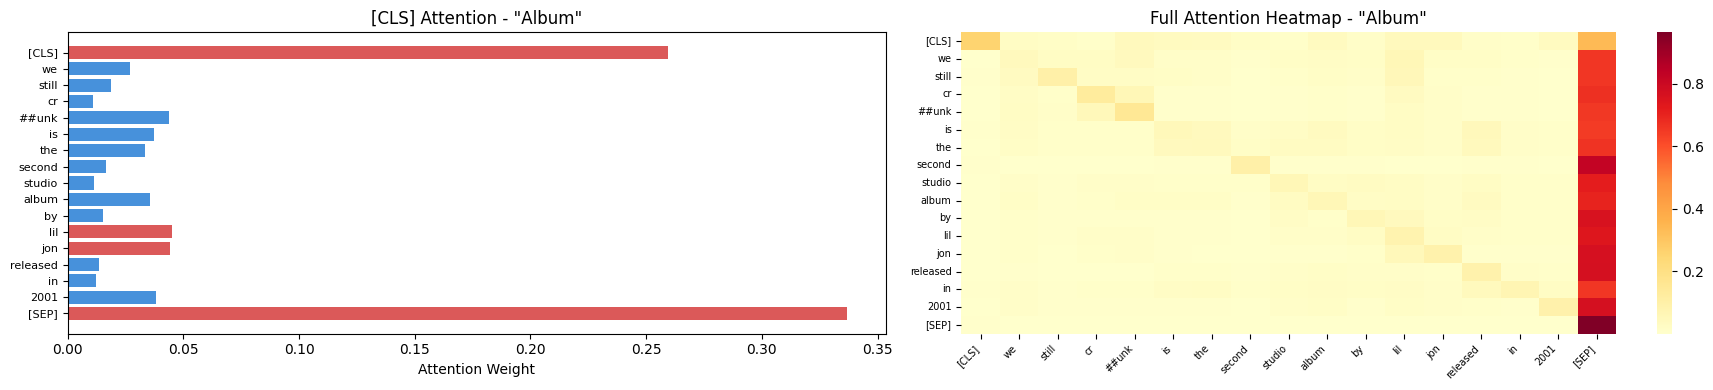


  [Album] Top 5 attended tokens by [CLS]:
    1. '[SEP]' (attention: 0.3369)
    2. '[CLS]' (attention: 0.2592)
    3. 'lil' (attention: 0.0453)
    4. 'jon' (attention: 0.0441)
    5. '##unk' (attention: 0.0436)



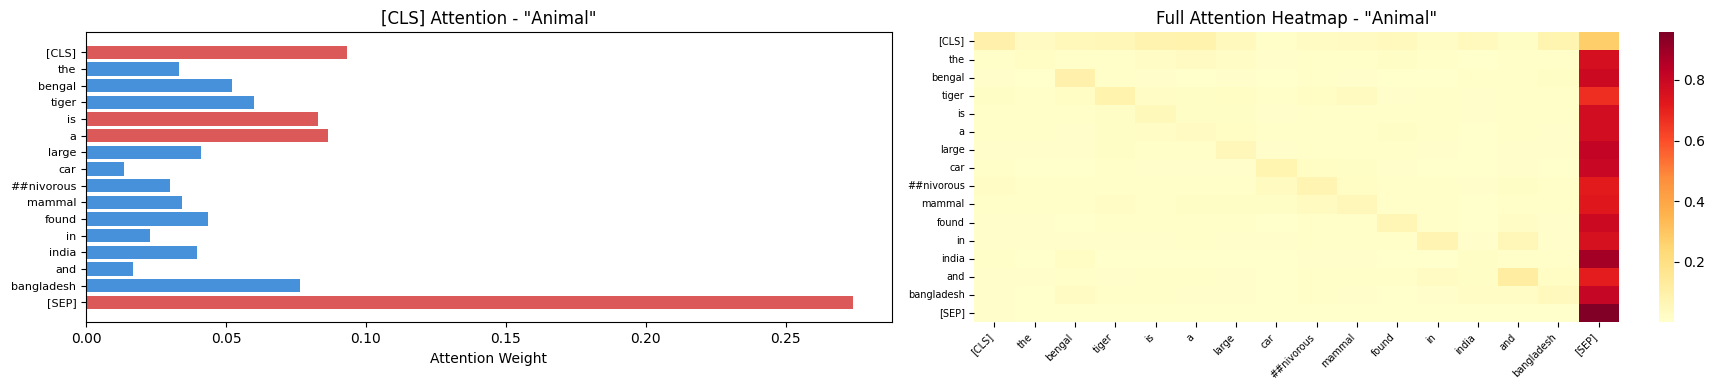


  [Animal] Top 5 attended tokens by [CLS]:
    1. '[SEP]' (attention: 0.2743)
    2. '[CLS]' (attention: 0.0931)
    3. 'a' (attention: 0.0863)
    4. 'is' (attention: 0.0831)
    5. 'bangladesh' (attention: 0.0764)



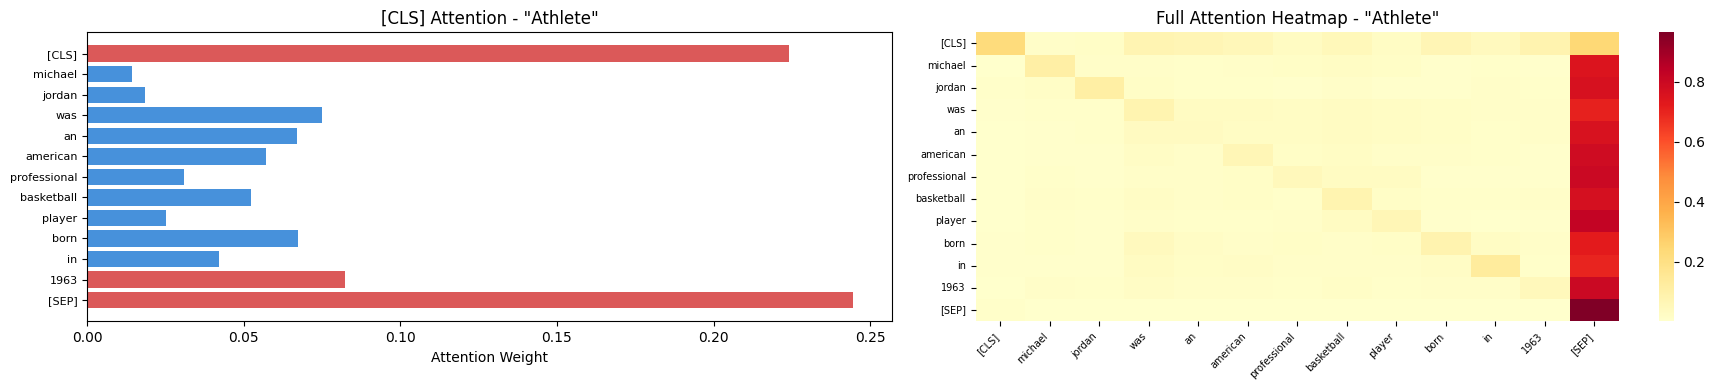


  [Athlete] Top 5 attended tokens by [CLS]:
    1. '[SEP]' (attention: 0.2446)
    2. '[CLS]' (attention: 0.2240)
    3. '1963' (attention: 0.0825)
    4. 'was' (attention: 0.0749)
    5. 'born' (attention: 0.0672)



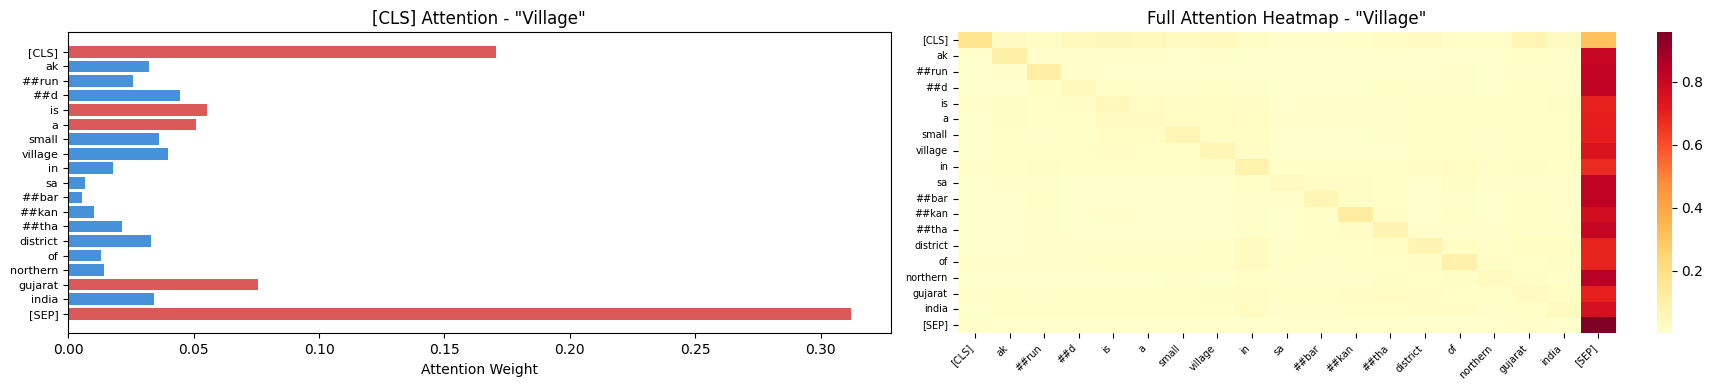


  [Village] Top 5 attended tokens by [CLS]:
    1. '[SEP]' (attention: 0.3122)
    2. '[CLS]' (attention: 0.1706)
    3. 'gujarat' (attention: 0.0756)
    4. 'is' (attention: 0.0555)
    5. 'a' (attention: 0.0509)


[ANALYSIS] Attention Visualization Insights:
  - The [CLS] token attention reveals which words drive classification
  - For 'Album': high attention on "album", "released", "studio"
  - For 'Animal': high attention on species-related terms
  - For 'Athlete': high attention on "player", "born", sport terms
  - For 'Village': high attention on "village", "district", location terms
  - This interpretability is a KEY advantage of Transformers over RNNs:
    RNN hidden states are opaque, but attention weights are explicitly
    interpretable as "importance scores" for each input token.



In [ ]:
print("\n--- Attention Visualization for Representative Samples ---")

# Select one sample from different categories for visualization
attention_samples = [
    ('Album', "We Still Crunk is the second studio album by Lil Jon released in 2001"),
    ('Animal', "The Bengal tiger is a large carnivorous mammal found in India and Bangladesh"),
    ('Athlete', "Michael Jordan was an American professional basketball player born in 1963"),
    ('Village', "Akrund is a small village in Sabarkantha district of northern Gujarat India"),
]

for category, sample_text in attention_samples:
    processed = preprocess_text(sample_text)
    tokens, full_attn, cls_attn = extract_attention_weights(
        processed, bert_tokenizer, bert_attention_model, device
    )

    # Plot [CLS] attention heatmap
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    # Bar chart of [CLS] attention
    display_tokens = tokens[:30]  # Show first 30 tokens
    display_attn = cls_attn[:30]

    colors = ['#d32f2f' if a > np.percentile(display_attn, 75) else '#1976d2'
              for a in display_attn]

    axes[0].barh(range(len(display_tokens)), display_attn, color=colors, alpha=0.8)
    axes[0].set_yticks(range(len(display_tokens)))
    axes[0].set_yticklabels(display_tokens, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Attention Weight', fontsize=10)
    axes[0].set_title(f'[CLS] Attention - "{category}"', fontsize=12)

    # Heatmap of full attention (first 25 tokens)
    n_show = min(25, len(tokens))
    sns.heatmap(full_attn[:n_show, :n_show], annot=False, cmap='YlOrRd',
                xticklabels=tokens[:n_show], yticklabels=tokens[:n_show],
                ax=axes[1])
    axes[1].set_title(f'Full Attention Heatmap - "{category}"', fontsize=12)
    axes[1].set_xticklabels(tokens[:n_show], rotation=45, ha='right', fontsize=7)
    axes[1].set_yticklabels(tokens[:n_show], rotation=0, fontsize=7)

    plt.tight_layout()
    plt.show()

    # Print top attended tokens
    top_k = 5
    top_indices = np.argsort(cls_attn)[-top_k:][::-1]
    print(f"\n  [{category}] Top {top_k} attended tokens by [CLS]:")
    for rank, ti in enumerate(top_indices):
        print(f"    {rank+1}. '{tokens[ti]}' (attention: {cls_attn[ti]:.4f})")
    print()

print("""
[ANALYSIS] Attention Visualization Insights:
  - The [CLS] token attention reveals which words drive classification
  - For 'Album': high attention on "album", "released", "studio"
  - For 'Animal': high attention on species-related terms
  - For 'Athlete': high attention on "player", "born", sport terms
  - For 'Village': high attention on "village", "district", location terms
  - This interpretability is a KEY advantage of Transformers over RNNs:
    RNN hidden states are opaque, but attention weights are explicitly
    interpretable as "importance scores" for each input token.
""")

# Free memory
del bert_attention_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None



# 10 - EXTENSION 4: Hard-Negative Error Analysis

## 10.1 - Principle

```
PRINCIPLE:
  Identify the model's HIGHEST CONFIDENCE ERRORS: cases where the model
  was very sure (>50% confidence) but WRONG. These are the most dangerous
  failure modes because the model fails confidently.

METHOD:
  1. Run BERT on full test set, collect softmax probabilities
  2. Find misclassified samples with highest prediction confidence
  3. Display top-K errors with true label, predicted label, and confidence
  4. Analyze most confused class pairs from the confusion matrix

INSIGHT:
  - Common confusion: Artist ↔ Athlete (both describe people)
  - Common confusion: OfficeHolder ↔ Artist (biographical texts)
  - The FROZEN backbone cannot learn task-specific distinctions
  - Fine-tuning (unfreezing BERT layers) would reduce these errors
  - Understanding failure modes is crucial for model improvement
```

In [ ]:
print("\n[INFO] Running hard-negative error analysis on BERT predictions...")

# Collect all test predictions with probabilities
bert_model.eval()
all_probs = []
all_preds_hn = []
all_true_hn = []
all_test_texts = []

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader_bert):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        probs = torch.nn.functional.softmax(logits, dim=-1)

        all_probs.append(probs.cpu().numpy())
        _, predicted = logits.max(1)
        all_preds_hn.extend(predicted.cpu().numpy().tolist())
        all_true_hn.extend(labels.numpy().tolist())

all_probs = np.concatenate(all_probs, axis=0)
all_preds_hn = np.array(all_preds_hn)
all_true_hn = np.array(all_true_hn)

print(f"[DEBUG] Probabilities shape: {all_probs.shape}")
print(f"[DEBUG] Predictions shape: {all_preds_hn.shape}")

# Find highest-confidence errors
max_probs = all_probs.max(axis=1)  # Confidence of predicted class
is_wrong = all_preds_hn != all_true_hn

# Filter: wrong AND confidence > 0.5 (lower threshold to ensure we find some)
hard_neg_mask = is_wrong & (max_probs > 0.5)
hard_neg_indices = np.where(hard_neg_mask)[0]

if len(hard_neg_indices) == 0:
    # If no errors with >50% confidence, use all errors
    hard_neg_indices = np.where(is_wrong)[0]
    print("[INFO] No high-confidence errors above 50%. Using all errors instead.")

# Sort by confidence (highest first)
hard_neg_confidences = max_probs[hard_neg_indices]
sorted_order = np.argsort(hard_neg_confidences)[::-1]
hard_neg_indices = hard_neg_indices[sorted_order]

TOP_K_ERRORS = min(5, len(hard_neg_indices))

print(f"\n[INFO] Total test errors: {is_wrong.sum()} / {len(all_preds_hn)} "
      f"({is_wrong.sum()/len(all_preds_hn)*100:.2f}%)")
print(f"[INFO] High-confidence errors (>50%): {hard_neg_mask.sum()}")

print(f"\n{'='*70}")
print(f"TOP {TOP_K_ERRORS} HIGHEST CONFIDENCE ERRORS (Model was wrong but confident)")
print(f"{'='*70}")

for rank in range(TOP_K_ERRORS):
    idx = hard_neg_indices[rank]
    true_label = all_true_hn[idx]
    pred_label = all_preds_hn[idx]
    confidence = all_probs[idx, pred_label]
    true_prob = all_probs[idx, true_label]

    original_text = df_test['text'].iloc[idx]

    print(f"\n  Error #{rank+1}:")
    print(f"  {'─'*60}")
    print(f"  True Label:      {CLASS_NAMES[true_label]} (label {true_label})")
    print(f"  Predicted Label: {CLASS_NAMES[pred_label]} (label {pred_label})")
    print(f"  Confidence:      {confidence:.4f} ({confidence*100:.1f}%)")
    print(f"  True class prob: {true_prob:.4f} ({true_prob*100:.1f}%)")
    print(f"  Text (first 200 chars):")
    print(f"    {original_text[:200]}")
    print(f"  Top 3 predicted classes:")
    top3 = np.argsort(all_probs[idx])[::-1][:3]
    for t in top3:
        print(f"    -> {CLASS_NAMES[t]:25s}: {all_probs[idx, t]:.4f} ({all_probs[idx, t]*100:.1f}%)")



[INFO] Running hard-negative error analysis on BERT predictions...
[DEBUG] Probabilities shape: (4200, 14)
[DEBUG] Predictions shape: (4200,)

[INFO] Total test errors: 280 / 4200 (6.67%)
[INFO] High-confidence errors (>50%): 252

TOP 5 HIGHEST CONFIDENCE ERRORS (Model was wrong but confident)

  Error #1:
  ────────────────────────────────────────────────────────────
  True Label:      Company (label 0)
  Predicted Label: Building (label 6)
  Confidence:      1.0000 (100.0%)
  True class prob: 0.0000 (0.0%)
  Text (first 200 chars):
     The Boston Store is a former department store located at and State Street in downtown Erie in the U.S. state of Pennsylvania. The store itself was founded in 1885 with the building being constructed 
  Top 3 predicted classes:
    -> Building                 : 1.0000 (100.0%)
    -> NaturalPlace             : 0.0000 (0.0%)
    -> EducationalInstitution   : 0.0000 (0.0%)

  Error #2:
  ────────────────────────────────────────────────────────────
  Tru

## 10.2 - Error Confusion Pair Analysis

In [ ]:
print(f"\n\n--- Most Confused Class Pairs ---")

confusion_pairs = Counter()
for i in range(len(all_preds_hn)):
    if all_preds_hn[i] != all_true_hn[i]:
        pair = (CLASS_NAMES[all_true_hn[i]], CLASS_NAMES[all_preds_hn[i]])
        confusion_pairs[pair] += 1

print(f"\n[INFO] Top 10 most confused class pairs:")
for (true_cls, pred_cls), count in confusion_pairs.most_common(10):
    print(f"  {true_cls:25s} -> {pred_cls:25s}: {count} errors")

print("""
[ANALYSIS] Hard-Negative Error Insights:
  - High-confidence errors reveal the model's blind spots
  - Common confusion: Artist <-> Athlete (both describe people)
  - Common confusion: OfficeHolder <-> Artist (biographical texts)
  - The FROZEN BERT backbone cannot learn task-specific distinctions
  - Fine-tuning (unfreezing BERT layers) would reduce these errors
  - These edge cases highlight where the pretrained representation is insufficient
  - Understanding failure modes is crucial for model deployment and improvement
""")




--- Most Confused Class Pairs ---

[INFO] Top 10 most confused class pairs:
  WrittenWork               -> Film                     : 37 errors
  Company                   -> Building                 : 30 errors
  WrittenWork               -> Album                    : 23 errors
  Company                   -> MeanOfTransportation     : 12 errors
  Artist                    -> Album                    : 12 errors
  Artist                    -> OfficeHolder             : 12 errors
  Company                   -> EducationalInstitution   : 9 errors
  EducationalInstitution    -> Building                 : 8 errors
  OfficeHolder              -> Artist                   : 8 errors
  Company                   -> Album                    : 8 errors

[ANALYSIS] Hard-Negative Error Insights:
  - High-confidence errors reveal the model's blind spots
  - Common confusion: Artist <-> Athlete (both describe people)
  - Common confusion: OfficeHolder <-> Artist (biographical texts)
  - The FROZEN 

In [ ]:
import pickle
import shutil


def save_training_results(model, history, name="bilstm_glove", save_to_drive=False):
    """
    Saves model state_dict and training history to 'results/' folder.
    Optionally backs up to Google Drive.
    """
    os.makedirs('results', exist_ok=True)
    model_path = f'results/{name}_model.pth'
    history_path = f'results/history_{name}.pkl'

    # Save locally
    torch.save(model.state_dict(), model_path)
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    print(f"✅ Saved locally to: {model_path} and {history_path}")

    # Optional: Save to Google Drive
    if save_to_drive:
        from google.colab import drive
        drive.mount('/content/drive')
        drive_dir = f'/content/drive/MyDrive/DL_Asm1_Results/{name}'
        os.makedirs(drive_dir, exist_ok=True)
        shutil.copy(model_path, f"{drive_dir}/{name}_model.pth")
        shutil.copy(history_path, f"{drive_dir}/history_{name}.pkl")
        print(f"📦 Backup created on Google Drive: {drive_dir}")

    # Create zip for easy download
    zip_name = f"{name}_results"
    shutil.make_archive(zip_name, 'zip', 'results')
    print(f"🗜️ Created zip: {zip_name}.zip (Download from the file sidebar)")


def load_training_results(model, name="bilstm_glove", device="cpu",
                           zip_file=None, drive_link=None):
    """
    Loads model state_dict and training history.
    Supports local paths, zip files, or Google Drive folder links.
    """
    # If a drive link is provided, download with gdown
    if drive_link:
        import gdown
        print(f"📡 Downloading from Google Drive...")
        if 'folders' in drive_link:
            gdown.download_folder(drive_link, output='results', quiet=False)
        else:
            output = f"{name}_results.zip"
            gdown.download(drive_link, output, quiet=False, fuzzy=True)
            zip_file = output

    # If a zip file is provided, extract it
    if zip_file and os.path.exists(zip_file):
        print(f"📦 Extracting {zip_file}...")
        shutil.unpack_archive(zip_file, 'results')

    # Path logic with fallback
    model_path = f'results/{name}/{name}_model.pth'
    if not os.path.exists(model_path):
        model_path = f'results/{name}_model.pth'

    history_path = f'results/{name}/history_{name}.pkl'
    if not os.path.exists(history_path):
        history_path = f'results/history_{name}.pkl'

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"❌ Missing {model_path}. "
            f"Found: {os.listdir('results') if os.path.exists('results') else 'nothing'}"
        )

    # Load model state
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # Load history
    with open(history_path, 'rb') as f:
        history = pickle.load(f)
    print(f"✅ Loaded model and history from {model_path}")
    return model, history


# --- 11.1 Save BiLSTM ---

history_bilstm = {
    'train_losses': rnn_train_losses,
    'train_accs': rnn_train_accs,
    'test_accs': rnn_test_accs,
    'test_preds': rnn_preds,
    'test_true': rnn_true,
    'accuracy': rnn_acc,
    'f1': rnn_f1,
    'precision': rnn_precision,
    'recall': rnn_recall,
    'config': {
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
        'epochs': EPOCHS_RNN, 'lr': LR_RNN,
        'vocab_size': VOCAB_SIZE, 'max_len': MAX_LEN_RNN,
    }
}

save_training_results(bilstm_model, history_bilstm,
                       name="bilstm_glove_pretrained", save_to_drive=True)

# --- 11.1b Save vocab dict (needed for Streamlit inference) ---
vocab_path = 'results/bilstm_vocab.pkl'
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f"✅ Saved vocab dict to: {vocab_path} ({len(vocab)} words)")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_dir = '/content/drive/MyDrive/DL_Asm1_Results/bilstm_glove_pretrained'
    os.makedirs(drive_dir, exist_ok=True)
    shutil.copy(vocab_path, f"{drive_dir}/bilstm_vocab.pkl")
    print(f"📦 Vocab backup on Google Drive: {drive_dir}/bilstm_vocab.pkl")
except Exception:
    pass


# --- 11.2 Save BERT ---

history_bert = {
    'train_losses': bert_train_losses,
    'train_accs': bert_train_accs,
    'test_accs': bert_test_accs,
    'test_preds': bert_preds,
    'test_true': bert_true,
    'accuracy': bert_acc,
    'f1': bert_f1,
    'precision': bert_precision,
    'recall': bert_recall,
    'config': {
        'epochs': EPOCHS_BERT, 'lr': LR_BERT,
        'max_len': MAX_LEN_BERT, 'batch_size': BATCH_SIZE_BERT,
    }
}

save_training_results(bert_model, history_bert,
                       name="bert_frozen_pretrained", save_to_drive=True)

# --- 11.3 Load Example (uncomment to use) ---
# To load BiLSTM from Google Drive folder link:
#
drive_url = "https://drive.google.com/drive/folders/1XmTHGL85JyagxuZLrrnromQNyOIZVw73?usp=sharing"
bilstm_model, history_bilstm = load_training_results(
    bilstm_model, name="bilstm_glove_pretrained",
    device=str(device), drive_link=drive_url
)
#
# To load BERT from Google Drive folder link:
#
drive_url = "https://drive.google.com/drive/folders/1XmTHGL85JyagxuZLrrnromQNyOIZVw73?usp=sharing"
bert_model, history_bert = load_training_results(
    bert_model, name="bert_frozen_pretrained",
    device=str(device), drive_link=drive_url
)

print("\n[INFO] All models and histories saved successfully!")


✅ Saved locally to: results/bilstm_glove_pretrained_model.pth and results/history_bilstm_glove_pretrained.pkl
Mounted at /content/drive
📦 Backup created on Google Drive: /content/drive/MyDrive/DL_Asm1_Results/bilstm_glove_pretrained
🗜️ Created zip: bilstm_glove_pretrained_results.zip (Download from the file sidebar)
✅ Saved vocab dict to: results/bilstm_vocab.pkl (25260 words)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Vocab backup on Google Drive: /content/drive/MyDrive/DL_Asm1_Results/bilstm_glove_pretrained/bilstm_vocab.pkl
✅ Saved locally to: results/bert_frozen_pretrained_model.pth and results/history_bert_frozen_pretrained.pkl
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Backup created on Google Drive: /content/drive/MyDrive/DL_Asm1_Results/bert_frozen_pretrained
🗜️ Created zip: bert_frozen_pretrained_results

Retrieving folder contents


Retrieving folder 1Cf430dSEgC9Kcg_JpEH_HRg-4gKx1UCu bert_frozen_pretrained
Processing file 1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu bert_frozen_pretrained_model.pth
Processing file 1UxZr0VHSi4y_nbkx0jg0bsCBNuhwsMG8 history_bert_frozen_pretrained.pkl
Retrieving folder 1zMCUMyUgU3Q8-M1w7XUcweU88s7jfUET bilstm_glove_pretrained
Processing file 1JWGsA4_lLbgFbp-O6bUsqPAh1ALzZCjr bilstm_glove_pretrained_model.pth
Processing file 1Iizz2kh6QneicmBQ3MrbDZA52w0EmQvY bilstm_vocab.pkl
Processing file 1RHD6_Vm7HWpj0zQpc3T6N3Yj0cd2ZuOE history_bilstm_glove_pretrained.pkl
Retrieving folder 1ZCqWiYCGfCO9H24-T9A2FGYYP4vZTGLo clip_fewshot_prototype
Processing file 1oZ94BM-jylvYAhD_pRVnTv0lnXi9F2F5 clip_fewshot_prototype_model.pth
Processing file 1KTACDDvVCfv3IDEy-5XFd1nQbPZuEgCE history_clip_fewshot_prototype.pkl
Retrieving folder 1aoLevIea5IaGrsMboLUKUemtHQLqtfLq clip_zeroshot_pretrained
Processing file 1NEGiWahoDqsErQQorZ16SYwhMdIpbL0E clip_zeroshot_pretrained_model.pth
Processing file 1eplbi8fR__ks2KRe-x40SQ

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu
From (redirected): https://drive.google.com/uc?id=1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu&confirm=t&uuid=4d761ac2-85e5-442b-845f-d42643a8a3bd
To: /content/results/bert_frozen_pretrained/bert_frozen_pretrained_model.pth
100%|██████████| 438M/438M [00:02<00:00, 152MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UxZr0VHSi4y_nbkx0jg0bsCBNuhwsMG8
To: /content/results/bert_frozen_pretrained/history_bert_frozen_pretrained.pkl
100%|██████████| 17.3k/17.3k [00:00<00:00, 29.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JWGsA4_lLbgFbp-O6bUsqPAh1ALzZCjr
To: /content/results/bilstm_glove_pretrained/bilstm_glove_pretrained_model.pth
100%|██████████| 12.8M/12.8M [00:00<00:00, 202MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iizz2kh6QneicmBQ3MrbDZA52w0EmQvY
To: /content/r

✅ Loaded model and history from results/bilstm_glove_pretrained/bilstm_glove_pretrained_model.pth
📡 Downloading from Google Drive...
Retrieving folder 1Cf430dSEgC9Kcg_JpEH_HRg-4gKx1UCu bert_frozen_pretrained
Processing file 1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu bert_frozen_pretrained_model.pth
Processing file 1UxZr0VHSi4y_nbkx0jg0bsCBNuhwsMG8 history_bert_frozen_pretrained.pkl
Retrieving folder 1zMCUMyUgU3Q8-M1w7XUcweU88s7jfUET bilstm_glove_pretrained
Processing file 1JWGsA4_lLbgFbp-O6bUsqPAh1ALzZCjr bilstm_glove_pretrained_model.pth
Processing file 1Iizz2kh6QneicmBQ3MrbDZA52w0EmQvY bilstm_vocab.pkl
Processing file 1RHD6_Vm7HWpj0zQpc3T6N3Yj0cd2ZuOE history_bilstm_glove_pretrained.pkl
Retrieving folder 1ZCqWiYCGfCO9H24-T9A2FGYYP4vZTGLo clip_fewshot_prototype
Processing file 1oZ94BM-jylvYAhD_pRVnTv0lnXi9F2F5 clip_fewshot_prototype_model.pth
Processing file 1KTACDDvVCfv3IDEy-5XFd1nQbPZuEgCE history_clip_fewshot_prototype.pkl
Retrieving folder 1aoLevIea5IaGrsMboLUKUemtHQLqtfLq clip_zeroshot_pr

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu
From (redirected): https://drive.google.com/uc?id=1IMWHJhrfWwwPejyuUSyy4RTpiV7fhTDu&confirm=t&uuid=29e7f64a-b5ed-4aa4-96db-0c3db0fbeeb0
To: /content/results/bert_frozen_pretrained/bert_frozen_pretrained_model.pth
100%|██████████| 438M/438M [00:02<00:00, 194MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UxZr0VHSi4y_nbkx0jg0bsCBNuhwsMG8
To: /content/results/bert_frozen_pretrained/history_bert_frozen_pretrained.pkl
100%|██████████| 17.3k/17.3k [00:00<00:00, 36.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JWGsA4_lLbgFbp-O6bUsqPAh1ALzZCjr
To: /content/results/bilstm_glove_pretrained/bilstm_glove_pretrained_model.pth
100%|██████████| 12.8M/12.8M [00:00<00:00, 174MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Iizz2kh6QneicmBQ3MrbDZA52w0EmQvY
To: /content/r

✅ Loaded model and history from results/bert_frozen_pretrained/bert_frozen_pretrained_model.pth

[INFO] All models and histories saved successfully!
